# 🔬 Clase 03 — RAG Simple vs RAG Mejorado
## Boletin Oficial de Salta · Edicion N° 21.922 · 31/03/2025

**Objetivo de la clase:** Demostrar con datos reales que las decisiones de diseño que revela el EDA (segmentación, metadatos, chunking inteligente) impactan directamente en la calidad del sistema RAG.

---

### 📚 Estructura del notebook

| Sección | Contenido |
|---|---|
| **Sección 1** | RAG *naive*: texto plano, chunks fijos, sin metadatos |
| **Sección 2** | RAG *mejorado*: segmentación por OP, metadatos, chunking legal |
| **Sección 3** | Evaluación comparativa con 2 métricas: Context Precision@K y MRR |

> 💡 **Premisa pedagógica:** El EDA no es un paso cosmético — es el paso que define la arquitectura del pipeline. Hoy lo vamos a demostrar empíricamente.


## 0. Setup e instalación

Usamos únicamente librerías estándar del ecosistema científico de Python.  
No se requiere GPU ni API key para correr este notebook.


In [1]:
!pip install -q scikit-learn pandas matplotlib seaborn numpy

In [2]:
import re, json, unicodedata
from collections import Counter
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Estilo global de plots ────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#f9fafb",
    "axes.facecolor":   "#ffffff",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})
PALETTE = ["#0D9488", "#7C3AED", "#F59E0B", "#EF4444", "#3B82F6", "#10B981"]
print("OK Setup completo")


OK Setup completo


## 📄 Corpus hardcodeado — Boletin Oficial de Salta

El corpus contiene los **12 documentos** extraídos del Boletin Oficial (Edicion N° 21.922, 31/03/2025). Están organizados por su marcador **OP N°**, el identificador único de cada publicación.

En producción este texto vendría del pipeline de ingesta con `pdfplumber` (ver Clase 02). Aquí lo hardcodeamos para que el notebook sea auto-contenido.


In [3]:
# ================================================================
# CORPUS COMPLETO -- 12 documentos del Boletin Oficial Salta
# Extraido con pdfplumber (pipeline Clase 02)
# ================================================================

DOCUMENTOS_RAW = [
  {"op_codigo": "SA100050325", "texto": (
    "LEY N 8488\n"
    "Ref. Expte. N 91-49.969/24\n"
    "EL SENADO Y LA CAMARA DE DIPUTADOS DE LA PROVINCIA, SANCIONAN CON FUERZA DE LEY\n"
    "Articulo 1.- Los cursos o carreras en materia de salud o educacion que se dicten o "
    "promocionen en el ambito de la provincia de Salta, deben encontrarse debidamente "
    "autorizados, homologados o certificados por las Autoridades Provinciales o Nacionales "
    "competentes en la materia para su validez, en el marco de la formacion docente continua.\n"
    "Art. 2.- La Autoridad de Aplicacion debe habilitar canales de consulta para cotejar y "
    "verificar si la oferta educativa se encuentra correctamente certificada.\n"
    "Art. 3.- En caso de detectarse el dictado de cursos o carreras que infrinjan lo dispuesto "
    "en el articulo 1, la Autoridad de Aplicacion ordenara la suspension inmediata del dictado "
    "y la persona humana o juridica responsable sera pasible de las siguientes sanciones:\n"
    "a) Apercibimiento.\n"
    "b) Multa de entre 50.000 y 100.000 unidades tributarias.\n"
    "Las sanciones previstas, lo son sin perjuicio de lo dispuesto en el Codigo Civil y "
    "Comercial de la Nacion.\n"
    "Art. 4.- El Poder Ejecutivo Provincial determina la Autoridad de Aplicacion de la "
    "presente Ley, la que coordinara acciones conjuntas con los Municipios.\n"
    "Art. 5.- Comuniquese al Poder Ejecutivo.\n"
    "SALTA, 27 de Marzo de 2025. DECRETO N 184.\n"
    "Tengase por Ley de la Provincia N 8488, cumplase, comuniquese, publiquese, "
    "insertese en el Registro Oficial de Leyes y archivese.\n"
    "SAENZ - Fiore Vinuales - De los Rios Plaza - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050311", "texto": (
    "SALTA, 25 de Marzo de 2025\n"
    "DECRETO N 167\n"
    "MINISTERIO DE GOBIERNO, DERECHOS HUMANOS Y TRABAJO\n"
    "Expediente N 0030041-32996/2025-0.\n"
    "VISTO la solicitud del Escribano Bruno Jose Bocanera, de otorgamiento de un Registro "
    "Notarial; y,\n"
    "CONSIDERANDO:\n"
    "Que motiva el pedido, el haber cumplido los 10 (diez) anos de adjuncion, conforme lo "
    "dispuesto por el articulo 2, inciso b) del Decreto Reglamentario N 2582/2000 de la Ley "
    "N 6486, y los demas requisitos establecidos en esta ultima;\n"
    "Que el Consejo Directivo del Colegio de Escribanos, mediante Acta N 2595 de fecha 6 de "
    "febrero de 2025, verifico que el Escribano Bocanera cumplimento con las obligaciones "
    "legales, profesionales y reglamentarias dispuestas por la citada normativa;\n"
    "Que ha tomado intervencion la Direccion General de Asuntos Juridicos del Ministerio de "
    "Gobierno, Derechos Humanos y Trabajo;\n"
    "Por ello, en ejercicio de las facultades conferidas por el articulo 4 de la Ley N 6486,\n"
    "EL GOBERNADOR DE LA PROVINCIA DE SALTA DECRETA:\n"
    "ARTICULO 1.- Designase al Escribano Bruno Jose Bocanera, D.N.I. N 31.904.457, como titular "
    "del Registro Notarial N 11, con asiento en la ciudad de Salta, en merito a las razones "
    "enunciadas en el considerando precedente.\n"
    "ARTICULO 2.- El presente decreto sera refrendado por el senor Ministro de Gobierno, "
    "Derechos Humanos y Trabajo, y por la senora Secretaria General de la Gobernacion.\n"
    "ARTICULO 3.- Comuniquese, publiquese en el Boletin Oficial y archivese.\n"
    "SAENZ - Villada - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050312", "texto": (
    "SALTA, 25 de Marzo de 2025\n"
    "DECRETO N 168\n"
    "MINISTERIO DE SEGURIDAD Y JUSTICIA\n"
    "Expediente N 0140044-100275/2024-0\n"
    "VISTO el pedido de Retiro Voluntario presentado por el Suboficial Principal de la Policia "
    "de la Provincia de Salta, Carlos Cristian Figueroa Rueda; y,\n"
    "CONSIDERANDO:\n"
    "Que de conformidad a las constancias de autos, se encuentran acreditados los requisitos "
    "exigidos para el pase a situacion de Retiro conforme lo establece el Acta Complementaria "
    "al Convenio de Transferencia del Sistema Provincial de Prevision Social, ratificada "
    "mediante el Decreto Nacional N 301/2006 y Decreto Provincial N 134/2006, ratificado "
    "mediante la Ley N 8128, razon por la cual corresponde conceder el beneficio invocado;\n"
    "Que la liquidacion tendiente a la determinacion del haber de retiro cuenta con el visado "
    "positivo de la Administracion Nacional de la Seguridad Social (ANSES) y de la Resolucion "
    "N 2060/2024 del Ministerio de Seguridad y Justicia, debidamente notificada al beneficiario;\n"
    "Que en la Clausula Octava del Convenio de Transferencia del Sistema Previsional de la "
    "Provincia de Salta al Estado Nacional, aprobado mediante Ley N 6818, se establece que el "
    "retiro del Personal de Seguridad debe disponerse por Decreto del Poder Ejecutivo Provincial;\n"
    "ARTICULO 1.- Disponese el pase a situacion de Retiro Voluntario del Suboficial Principal "
    "de la Policia de la Provincia de Salta, Carlos Cristian Figueroa Rueda, D.N.I. N 27.465.890, "
    "Clase 1979, Legajo Personal N 13.818, Cuerpo Seguridad Escalafon General.\n"
    "ARTICULO 2.- En forma previa a hacerse efectivo el pase a retiro, el agente debera hacer "
    "uso de las licencias anuales reglamentarias y/o compensatorias pendientes de usufructuar.\n"
    "ARTICULO 3.- El Suboficial Principal Carlos Cristian Figueroa Rueda, Legajo Personal N "
    "13.818, quedara fuera del fraccionamiento normado en el articulo 8 inciso c) del Decreto "
    "N 248/1975, como asi tambien de la aplicacion del articulo 21 del Decreto N 1950/1977.\n"
    "ARTICULO 4.- El presente decreto sera refrendado por el senor Ministro de Seguridad y "
    "Justicia, y por la senora Secretaria General de la Gobernacion.\n"
    "ARTICULO 5.- Comuniquese, publiquese en el Boletin Oficial y archivese.\n"
    "SAENZ - Sola Usandivaras - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050313", "texto": (
    "SALTA, 25 de Marzo de 2025\n"
    "DECRETO N 169\n"
    "MINISTERIO DE SEGURIDAD Y JUSTICIA\n"
    "Expediente N 0140044-106733/2024-0\n"
    "VISTO la solicitud de Retiro Voluntario presentada por el Suboficial Principal de la "
    "Policia de la Provincia de Salta, Julio Blas Guaimas; y,\n"
    "CONSIDERANDO:\n"
    "Que de conformidad a las constancias de autos, se encuentran acreditados los requisitos "
    "exigidos para el pase a situacion de Retiro conforme lo establece el Acta Complementaria "
    "al Convenio de Transferencia del Sistema Provincial de Prevision Social, ratificada "
    "mediante el Decreto Nacional N 301/2006 y Decreto Provincial N 134/2006, ratificado "
    "mediante la Ley N 8128;\n"
    "Que la liquidacion del haber de retiro cuenta con el visado positivo de ANSES y de la "
    "Resolucion N 2093/2024 del Ministerio de Seguridad y Justicia;\n"
    "ARTICULO 1.- Disponese el pase a situacion de Retiro Voluntario del Suboficial Principal "
    "de la Policia de la Provincia de Salta, Julio Blas Guaimas, D.N.I. N 21.312.199, "
    "Clase 1970, Legajo Personal N 13.381, Cuerpo Seguridad Escalafon General.\n"
    "ARTICULO 2.- En forma previa debera hacer uso de las licencias anuales reglamentarias "
    "y/o compensatorias pendientes de usufructuar.\n"
    "ARTICULO 3.- El Suboficial Principal Julio Blas Guaimas, Legajo Personal N 13.381, "
    "quedara fuera del fraccionamiento normado en el articulo 8 inciso c) del Decreto N "
    "248/1975, como asi tambien de la aplicacion del articulo 21 del Decreto N 1950/1977.\n"
    "ARTICULO 4.- El presente decreto sera refrendado por el senor Ministro de Seguridad "
    "y Justicia.\n"
    "ARTICULO 5.- Comuniquese, publiquese en el Boletin Oficial y archivese.\n"
    "SAENZ - Sola Usandivaras - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050314", "texto": (
    "SALTA, 25 de Marzo de 2025\n"
    "DECRETO N 170\n"
    "MINISTERIO DE SEGURIDAD Y JUSTICIA\n"
    "Expediente N 0140044-140618/2024-0\n"
    "VISTO el pedido de Retiro Voluntario presentado por el Suboficial Mayor de la Policia "
    "de la Provincia de Salta, Alberto del Milagro Bonifacio; y,\n"
    "CONSIDERANDO:\n"
    "Que de conformidad a las constancias de autos, se encuentran acreditados los requisitos "
    "exigidos para el pase a situacion de Retiro conforme lo establece el Acta Complementaria "
    "al Convenio de Transferencia del Sistema Provincial de Prevision Social, ratificada "
    "mediante el Decreto Nacional N 301/2006 y Decreto Provincial N 134/2006;\n"
    "Que la liquidacion del haber de retiro cuenta con el visado positivo de ANSES y de la "
    "Resolucion N 2173/2024 del Ministerio de Seguridad y Justicia;\n"
    "ARTICULO 1.- Disponese el pase a situacion de Retiro Voluntario del Suboficial Mayor "
    "de la Policia de la Provincia de Salta, Alberto del Milagro Bonifacio, D.N.I. N "
    "25.122.446, Legajo Personal N 13.403, Clase 1976, Cuerpo Seguridad Escalafon General.\n"
    "ARTICULO 2.- En forma previa debera hacer uso de las licencias anuales reglamentarias "
    "y/o compensatorias pendientes de usufructuar.\n"
    "ARTICULO 3.- El Suboficial Mayor Alberto del Milagro Bonifacio quedara fuera del "
    "fraccionamiento normado en el articulo 8 inciso c) del Decreto N 248/1975.\n"
    "ARTICULO 4.- El presente decreto sera refrendado por el senor Ministro de Seguridad.\n"
    "ARTICULO 5.- Comuniquese, publiquese en el Boletin Oficial y archivese.\n"
    "SAENZ - Sola Usandivaras - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050315", "texto": (
    "SALTA, 25 de Marzo de 2025\n"
    "DECRETO N 171\n"
    "MINISTERIO DE SEGURIDAD Y JUSTICIA\n"
    "Expediente N 0140044-113886/2024-0\n"
    "VISTO el pedido de Retiro Voluntario presentado por el Suboficial Mayor de la Policia "
    "de la Provincia de Salta, Javier Alberto Flores Cabana; y,\n"
    "CONSIDERANDO:\n"
    "Que de conformidad a las constancias de autos se encuentran acreditados los requisitos "
    "exigidos para el pase a situacion de Retiro conforme lo establece el Acta Complementaria "
    "al Convenio de Transferencia del Sistema Provincial de Prevision Social;\n"
    "Que la liquidacion del haber de retiro cuenta con el visado positivo de ANSES y de la "
    "Resolucion N 2078/2024 del Ministerio de Seguridad y Justicia;\n"
    "ARTICULO 1.- Disponese el pase a situacion de Retiro Voluntario del Suboficial Mayor "
    "de la Policia de la Provincia de Salta, Javier Alberto Flores Cabana, D.N.I. N "
    "22.945.314, Clase 1972, Legajo Personal N 13.510, Cuerpo Seguridad Escalafon General.\n"
    "ARTICULO 2.- En forma previa debera hacer uso de las licencias anuales reglamentarias "
    "y/o compensatorias pendientes de usufructuar.\n"
    "ARTICULO 3.- El Suboficial Mayor Flores Cabana quedara fuera del fraccionamiento normado "
    "en el articulo 8 inciso c) del Decreto N 248/1975.\n"
    "ARTICULO 4.- El presente decreto sera refrendado por el senor Ministro de Seguridad.\n"
    "ARTICULO 5.- Comuniquese, publiquese en el Boletin Oficial y archivese.\n"
    "SAENZ - Sola Usandivaras - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050316", "texto": (
    "SALTA, 25 de Marzo de 2025\n"
    "DECRETO N 172\n"
    "MINISTERIO DE SEGURIDAD Y JUSTICIA\n"
    "Expediente N 0140044-84758/2024-0\n"
    "VISTO el pedido de Retiro Voluntario presentado por el Suboficial Principal de la "
    "Policia de la Provincia de Salta, Jorge Felipe Edgardo Salas; y,\n"
    "CONSIDERANDO:\n"
    "Que de conformidad a las constancias de autos se encuentran acreditados los requisitos "
    "exigidos para el pase a situacion de Retiro conforme lo establece el Acta Complementaria "
    "al Convenio de Transferencia del Sistema Provincial de Prevision Social;\n"
    "Que la liquidacion del haber de retiro cuenta con el visado positivo de ANSES y de la "
    "Resolucion N 2092/2024 del Ministerio de Seguridad y Justicia;\n"
    "ARTICULO 1.- Disponese el pase a situacion de Retiro Voluntario del Suboficial Principal "
    "de la Policia de la Provincia de Salta, Jorge Felipe Edgardo Salas, D.N.I. N 28.124.630, "
    "Clase 1980, Legajo Personal N 16.601, Cuerpo Seguridad Escalafon General.\n"
    "ARTICULO 2.- En forma previa debera hacer uso de las licencias anuales reglamentarias "
    "y/o compensatorias pendientes de usufructuar.\n"
    "ARTICULO 3.- El Suboficial Principal Salas quedara fuera del fraccionamiento normado en "
    "el articulo 8 inciso c) del Decreto N 248/1975.\n"
    "ARTICULO 4.- El presente decreto sera refrendado por el senor Ministro de Seguridad.\n"
    "ARTICULO 5.- Comuniquese, publiquese en el Boletin Oficial y archivese.\n"
    "SAENZ - Sola Usandivaras - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050317", "texto": (
    "SALTA, 25 de Marzo de 2025\n"
    "DECRETO N 173\n"
    "MINISTERIO DE SEGURIDAD Y JUSTICIA\n"
    "Expediente N 0140044-139217/2024-0\n"
    "VISTO el pedido de Retiro Voluntario presentado por la Suboficial Mayor de la Policia "
    "de la Provincia de Salta, Claudia Elizabet Gomez Posse; y,\n"
    "CONSIDERANDO:\n"
    "Que de conformidad a las constancias de autos se encuentran acreditados los requisitos "
    "exigidos para el pase a situacion de Retiro conforme lo establece el Acta Complementaria "
    "al Convenio de Transferencia del Sistema Provincial de Prevision Social;\n"
    "Que la liquidacion del haber de retiro cuenta con el visado positivo de ANSES y de la "
    "Resolucion N 182/2025 del Ministerio de Seguridad y Justicia;\n"
    "ARTICULO 1.- Disponese el pase a situacion de Retiro Voluntario de la Suboficial Mayor "
    "de la Policia de la Provincia de Salta, Claudia Elizabet Gomez Posse, D.N.I. N "
    "29.164.778, Legajo Personal N 13.976, Clase 1982, Cuerpo Seguridad Escalafon General.\n"
    "ARTICULO 2.- En forma previa debera hacer uso de las licencias anuales reglamentarias "
    "y/o compensatorias pendientes de usufructuar.\n"
    "ARTICULO 3.- La Suboficial Mayor Claudia Elizabet Gomez Posse quedara fuera del "
    "fraccionamiento normado en el articulo 8 inciso c) del Decreto N 248/1975.\n"
    "ARTICULO 4.- El presente decreto sera refrendado por el senor Ministro de Seguridad.\n"
    "ARTICULO 5.- Comuniquese, publiquese en el Boletin Oficial y archivese.\n"
    "SAENZ - Sola Usandivaras - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050318", "texto": (
    "SALTA, 25 de Marzo de 2025\n"
    "DECRETO N 174\n"
    "MINISTERIO DE SEGURIDAD Y JUSTICIA\n"
    "Expediente N 0140050-235085/2024-0\n"
    "VISTO la solicitud de Retiro Voluntario presentada por el Sargento Ayudante del Servicio "
    "Penitenciario de la Provincia de Salta, Diego Fernando Rico; y,\n"
    "CONSIDERANDO:\n"
    "Que de conformidad a las constancias de autos se encuentran acreditados los requisitos "
    "exigidos para el pase a situacion de Retiro conforme lo establece el Acta Complementaria "
    "al Convenio de Transferencia del Sistema Provincial de Prevision Social, ratificada "
    "mediante el Decreto Nacional N 301/2006 y Decreto Provincial N 134/2006, ratificado "
    "mediante la Ley N 8128;\n"
    "Que la liquidacion del haber de retiro cuenta con el visado positivo de ANSES y de la "
    "Resolucion N 108/2025 del Ministerio de Seguridad y Justicia;\n"
    "ARTICULO 1.- Disponese el pase a situacion de Retiro Voluntario del Sargento Ayudante "
    "del Servicio Penitenciario de la Provincia de Salta, Diego Fernando Rico, D.N.I. N "
    "30.636.175, Clase 1984, Legajo Personal N 1908, Escalafon Penitenciario.\n"
    "ARTICULO 2.- En forma previa debera hacer uso de las licencias anuales reglamentarias "
    "y/o compensatorias pendientes de usufructuar.\n"
    "ARTICULO 3.- El presente decreto sera refrendado por el senor Ministro de Seguridad.\n"
    "ARTICULO 4.- Comuniquese, publiquese en el Boletin Oficial y archivese.\n"
    "SAENZ - Sola Usandivaras - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050326", "texto": (
    "SALTA, 28 de Marzo de 2025\n"
    "DECRETO N 188\n"
    "MINISTERIO DE SEGURIDAD Y JUSTICIA\n"
    "Expediente N 341-53161/2025.\n"
    "VISTO la renuncia presentada por la Dra. Maria Veronica Saicha Ibanez, al cargo de "
    "Secretaria de Justicia; y,\n"
    "Por ello,\n"
    "EL GOBERNADOR DE LA PROVINCIA DE SALTA DECRETA:\n"
    "ARTICULO 1.- Aceptase la renuncia presentada por la Dra. Maria Veronica Saicha Ibanez, "
    "DNI N 20.339.284, al cargo de Secretaria de Justicia, a partir de la fecha del presente, "
    "dandoseles las gracias por los servicios prestados.\n"
    "ARTICULO 2.- El presente decreto sera refrendado por el senor Ministro de Seguridad y "
    "Justicia y por la senora Secretaria General de la Gobernacion.\n"
    "ARTICULO 3.- Comuniquese, publiquese en el Boletin Oficial y archivese.\n"
    "SAENZ - Sola Usandivaras - Lopez Morillo.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050295", "texto": (
    "SALTA, 21 de Marzo de 2025\n"
    "DECISION ADMINISTRATIVA N 110\n"
    "MINISTERIO DE EDUCACION, CULTURA, CIENCIA Y TECNOLOGIA\n"
    "EXPEDIENTE N 0120047-47559/2024-0\n"
    "VISTO el pedido de afectacion de la Sra. Salazar Arce, Carolina Marianela, personal del "
    "Ministerio de Educacion, Cultura, Ciencia y Tecnologia de la provincia de Salta al "
    "Concejo Deliberante de la Ciudad de Salta; y\n"
    "CONSIDERANDO:\n"
    "Que la afectacion es una medida de excepcion y de caracter transitorio, por la cual se "
    "admite la afectacion en forma no permanente por parte de un agente en otra dependencia, "
    "para la realizacion de tareas especificas, estando su vigencia condicionada a las razones "
    "que la originaron;\n"
    "Que, en tal sentido, las autoridades correspondientes prestan conformidad al presente "
    "tramite;\n"
    "Por ello, con arreglo a lo establecido por el articulo 13 de la Ley N 8171 y modificada "
    "por su similar Ley N 8274 y el articulo 1 inciso D) de la Resolucion N 16/2021 del "
    "Ministerio de Economia y Servicios Publicos;\n"
    "ARTICULO 1.- Autorizar la afectacion de la Sra. Salazar Arce, Carolina Marianela, D.N.I. "
    "N 30.221.491, personal del Ministerio de Educacion al Concejo Deliberante de la Ciudad "
    "de Salta, a partir del 01 de enero de 2025 y hasta el 31 de diciembre de 2025, o "
    "mientras duren las necesidades de servicio, lo que suceda primero.\n"
    "ARTICULO 2.- El presente Acto Administrativo sera refrendado por la senora Ministra de "
    "Educacion, Cultura, Ciencia, y Tecnologia.\n"
    "ARTICULO 3.- Comunicar, publicar en el Boletin Oficial y archivar.\n"
    "Demetropulos - Fiore Vinuales.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
  {"op_codigo": "SA100050296", "texto": (
    "SALTA, 21 de Marzo de 2025\n"
    "DECISION ADMINISTRATIVA N 111\n"
    "MINISTERIO DE EDUCACION, CULTURA, CIENCIA Y TECNOLOGIA\n"
    "EXPEDIENTE N 0120047-27207/2025-0\n"
    "VISTO el pedido de afectacion de la Sra. Testa, Noelia Alejandra, personal del "
    "Ministerio de Educacion, Cultura, Ciencia y Tecnologia de la provincia de Salta, "
    "al Concejo Deliberante de la Ciudad de Salta; y\n"
    "CONSIDERANDO:\n"
    "Que la afectacion es una medida de excepcion y de caracter transitorio, por la cual se "
    "admite la afectacion en forma no permanente por parte de un agente en otra dependencia, "
    "para la realizacion de tareas especificas, estando su vigencia condicionada a las razones "
    "que la originaron;\n"
    "Que, en tal sentido, las autoridades correspondientes prestan conformidad al presente "
    "tramite;\n"
    "Por ello, con arreglo a lo establecido por el articulo 13 de la Ley N 8171 y modificada "
    "por su similar Ley N 8274 y el articulo 1 inciso D) de la Resolucion N 16/2021 del "
    "Ministerio de Economia y Servicios Publicos;\n"
    "ARTICULO 1.- Autorizar la afectacion de la Sra. Testa, Noelia Alejandra, D.N.I. N "
    "29.640.497, personal del Ministerio de Educacion al Concejo Deliberante de la Ciudad "
    "de Salta, a partir del 01 de enero de 2025 y hasta el 31 de diciembre de 2025, o "
    "mientras duren las necesidades de servicio, lo que suceda primero.\n"
    "ARTICULO 2.- El presente Acto Administrativo sera refrendado por la senora Ministra de "
    "Educacion, Cultura, Ciencia, y Tecnologia.\n"
    "ARTICULO 3.- Comunicar, publicar en el Boletin Oficial y archivar.\n"
    "Demetropulos - Fiore Vinuales.\n"
    "Fechas de publicacion: 31/03/2025"
  )},
]

print(f"OK Corpus cargado: {len(DOCUMENTOS_RAW)} documentos")
total_chars = sum(len(d['texto']) for d in DOCUMENTOS_RAW)
print(f"   Total de caracteres: {total_chars:,}")
total_palabras = sum(len(d['texto'].split()) for d in DOCUMENTOS_RAW)
print(f"   Total de palabras:   {total_palabras:,}")


OK Corpus cargado: 12 documentos
   Total de caracteres: 18,021
   Total de palabras:   2,787


---
# 🔴 SECCION 1 — RAG Naive (sin mejoras del EDA)

## Que es un RAG *naive*?

Un RAG naive (ingenuo) es el punto de partida mas simple posible:

1. **Concatenar** todo el corpus en un unico texto plano
2. **Dividir** en chunks de tamano fijo (sin respetar estructura)
3. **Vectorizar** con TF-IDF
4. **Recuperar** los K chunks mas similares por coseno

> Aviso **Problema de diseno:** Sin segmentacion, un unico chunk puede mezclar
> texto de dos documentos distintos. Sin metadatos, no sabemos de que
> documento vino cada chunk. Sin separadores inteligentes, cortamos en
> medio de articulos legales.


### 1.1 Chunking fijo — el problema mas comun

Punto **Fixed-size chunking**: dividir cada N palabras, con un overlap fijo.  
Es simple de implementar pero ignora completamente la estructura del texto.

En un boletin legal, esto genera chunks que:
- Cortan un articulo a la mitad
- Mezclan el final de un decreto con el inicio del siguiente
- No tienen ninguna referencia al documento de origen


In [4]:
# ================================================================
# RAG NAIVE -- Paso 1: Concatenar corpus y chunking fijo
# ================================================================

def chunk_fijo(texto: str, tam_palabras: int = 150, overlap: int = 20) -> List[str]:
    """
    Divide el texto en chunks de tamano fijo (en palabras).

    Parametros:
        tam_palabras: cantidad de palabras por chunk
        overlap:      palabras que se repiten entre chunks consecutivos

    Limitacion clave: NO respeta ninguna estructura del documento.
    Un chunk puede empezar en medio de una oracion o articulo.
    """
    palabras = texto.split()
    chunks = []
    paso = tam_palabras - overlap

    for i in range(0, len(palabras), paso):
        chunk = ' '.join(palabras[i : i + tam_palabras])
        if len(chunk.split()) >= 30:   # filtrar chunks muy cortos
            chunks.append(chunk)
    return chunks

# Concatenar TODO el corpus en un unico string
CORPUS_CONCATENADO = '\n\n'.join(doc['texto'] for doc in DOCUMENTOS_RAW)
print(f'Corpus concatenado: {len(CORPUS_CONCATENADO):,} caracteres')
print()

# Aplicar chunking fijo
CHUNKS_NAIVE = chunk_fijo(CORPUS_CONCATENADO, tam_palabras=150, overlap=20)
print(f'Chunks generados (naive):   {len(CHUNKS_NAIVE)}')
print(f'Tamano promedio (palabras): {int(sum(len(c.split()) for c in CHUNKS_NAIVE)/len(CHUNKS_NAIVE))}')
print()

# DEMOSTRACION DEL PROBLEMA: chunks que cruzan documentos
print('PROBLEMA DETECTADO -- chunks en la frontera entre documentos:')
print('-' * 70)
for i, chunk in enumerate(CHUNKS_NAIVE):
    if 'archivese' in chunk.lower() and 'DECRETO' in chunk and i > 2:
        print(f'Chunk N {i}:')
        print(chunk[:400])
        print('\nEste chunk mezcla el FINAL de un decreto con el INICIO del siguiente!')
        break


Corpus concatenado: 18,043 caracteres

Chunks generados (naive):   22
Tamano promedio (palabras): 145

PROBLEMA DETECTADO -- chunks en la frontera entre documentos:
----------------------------------------------------------------------
Chunk N 3:
N 6486, EL GOBERNADOR DE LA PROVINCIA DE SALTA DECRETA: ARTICULO 1.- Designase al Escribano Bruno Jose Bocanera, D.N.I. N 31.904.457, como titular del Registro Notarial N 11, con asiento en la ciudad de Salta, en merito a las razones enunciadas en el considerando precedente. ARTICULO 2.- El presente decreto sera refrendado por el senor Ministro de Gobierno, Derechos Humanos y Trabajo, y por la sen

Este chunk mezcla el FINAL de un decreto con el INICIO del siguiente!


### 1.2 Vectorizacion TF-IDF y retrieval naive

Punto **TF-IDF** (*Term Frequency-Inverse Document Frequency*) es el baseline clasico de recuperacion de informacion. Funciona bien con terminos tecnicos poco comunes (ANSES, legajo, etc.) pero no captura semantica.

> Llave **Decision de diseno:** Para este corpus en espanol con vocabulario legal especializado, TF-IDF es un baseline competitivo. Lo usamos aqui para aislar el efecto de la *estrategia de chunking y metadatos*, no del modelo de embedding.


In [5]:
# ================================================================
# RAG NAIVE -- Paso 2: Vectorizacion TF-IDF
# ================================================================

# ngram_range=(1,2): unigramas + bigramas
# captura 'retiro voluntario', 'suboficial principal', 'poder ejecutivo'
vectorizador_naive = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True,  # TF logaritmico: reduce dominancia de terminos frecuentes
)

MATRIZ_NAIVE = vectorizador_naive.fit_transform(CHUNKS_NAIVE)
print(f'Matriz TF-IDF (naive):')
print(f'  Chunks x Terminos: {MATRIZ_NAIVE.shape}')
print(f'  Densidad:          {MATRIZ_NAIVE.nnz / (MATRIZ_NAIVE.shape[0]*MATRIZ_NAIVE.shape[1]):.4%}')
print()

def recuperar_naive(query: str, k: int = 5) -> List[Dict]:
    """
    Recupera los k chunks mas similares a la query.
    Limitacion: sin metadatos, no sabemos a que documento pertenece cada chunk.
    """
    vec_query = vectorizador_naive.transform([query])
    sims = cosine_similarity(vec_query, MATRIZ_NAIVE).flatten()
    top_k_idx = sims.argsort()[::-1][:k]
    return [
        {
            'rank':      int(idx),
            'score':     float(sims[idx]),
            'texto':     CHUNKS_NAIVE[idx],
            'op_codigo': 'DESCONOCIDA',  # sin metadata!
        }
        for idx in top_k_idx
    ]

print('OK Vectorizador naive construido -- recuperar_naive() disponible')


Matriz TF-IDF (naive):
  Chunks x Terminos: (22, 1403)
  Densidad:          14.3718%

OK Vectorizador naive construido -- recuperar_naive() disponible


### 1.3 Consultas de prueba — RAG Naive en accion

Probamos 5 preguntas y observamos: el chunk recuperado responde la pregunta? Podemos saber de que documento vino?


In [6]:
# ================================================================
# RAG NAIVE -- Paso 3: Consultas de prueba
# ================================================================

CONSULTAS = [
    'Quien fue designado como titular del Registro Notarial N 11?',
    'Cuales son las sanciones de la Ley 8488 por cursos no autorizados?',
    'Quien renuncio al cargo de Secretaria de Justicia?',
    'Que legajo tiene Carlos Cristian Figueroa Rueda?',
    'Hasta cuando dura la afectacion de la Sra. Salazar Arce al Concejo Deliberante?',
]

print('=' * 70)
print('RESULTADOS RAG NAIVE -- Top-1 para cada consulta')
print('=' * 70)

for q in CONSULTAS:
    res = recuperar_naive(q, k=1)[0]
    print(f'\nQUERY: {q}')
    print(f'  Score:   {res["score"]:.4f}')
    print(f'  OP:      {res["op_codigo"]}  <- siempre DESCONOCIDA')
    print(f'  Chunk:   {res["texto"][:180]}...')
    print('-' * 70)


RESULTADOS RAG NAIVE -- Top-1 para cada consulta

QUERY: Quien fue designado como titular del Registro Notarial N 11?
  Score:   0.2876
  OP:      DESCONOCIDA  <- siempre DESCONOCIDA
  Chunk:   N 6486, EL GOBERNADOR DE LA PROVINCIA DE SALTA DECRETA: ARTICULO 1.- Designase al Escribano Bruno Jose Bocanera, D.N.I. N 31.904.457, como titular del Registro Notarial N 11, con a...
----------------------------------------------------------------------

QUERY: Cuales son las sanciones de la Ley 8488 por cursos no autorizados?
  Score:   0.1424
  OP:      DESCONOCIDA  <- siempre DESCONOCIDA
  Chunk:   LEY N 8488 Ref. Expte. N 91-49.969/24 EL SENADO Y LA CAMARA DE DIPUTADOS DE LA PROVINCIA, SANCIONAN CON FUERZA DE LEY Articulo 1.- Los cursos o carreras en materia de salud o educa...
----------------------------------------------------------------------

QUERY: Quien renuncio al cargo de Secretaria de Justicia?
  Score:   0.2544
  OP:      DESCONOCIDA  <- siempre DESCONOCIDA
  Chunk:   ARTICULO 1

### 1.4 Visualizacion de scores (naive)

Un score bajo o poca separacion entre el Top-1 y el resto indica retrieval impreciso.


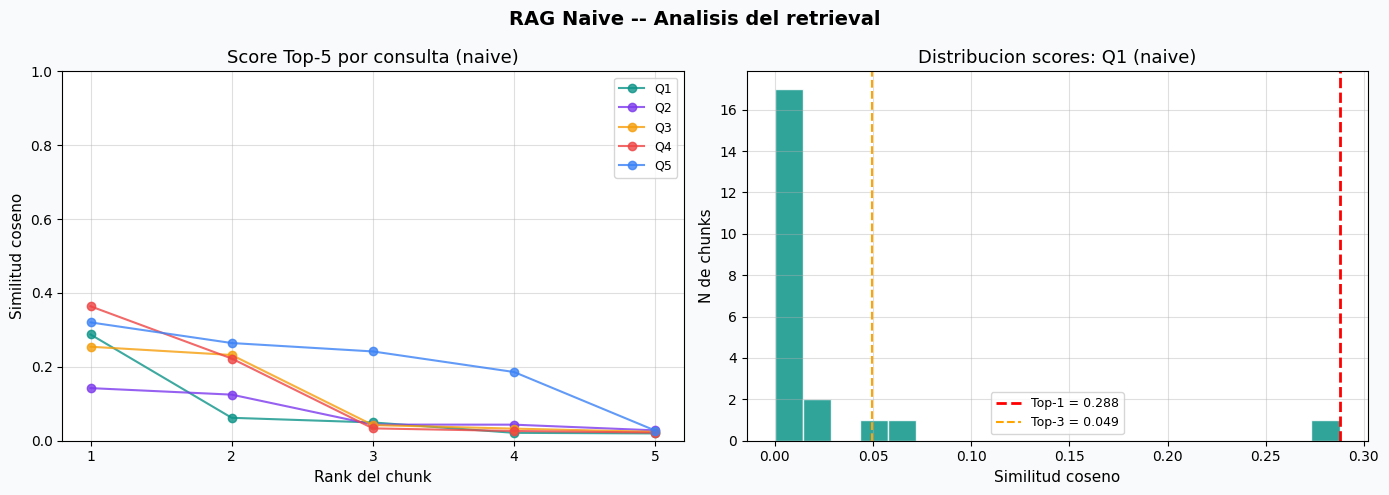

Nota: scores bajos y poco separados -> retrieval impreciso.


In [7]:
# ================================================================
# RAG NAIVE -- Visualizacion de scores por consulta
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RAG Naive -- Analisis del retrieval', fontweight='bold', fontsize=14)

ax = axes[0]
colores = PALETTE[:len(CONSULTAS)]
for i, (q, color) in enumerate(zip(CONSULTAS, colores)):
    scores = [r['score'] for r in recuperar_naive(q, k=5)]
    ax.plot(range(1, 6), scores, 'o-', color=color, label=f'Q{i+1}', alpha=0.8)
ax.set_title('Score Top-5 por consulta (naive)')
ax.set_xlabel('Rank del chunk')
ax.set_ylabel('Similitud coseno')
ax.set_xticks(range(1, 6))
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1)

ax = axes[1]
q_test = CONSULTAS[0]
vec_q = vectorizador_naive.transform([q_test])
sims_all = cosine_similarity(vec_q, MATRIZ_NAIVE).flatten()
ax.hist(sims_all, bins=20, color=PALETTE[0], edgecolor='white', alpha=0.85)
top1 = sorted(sims_all)[-1]
top3 = sorted(sims_all)[-3]
ax.axvline(top1, color='red', lw=2, ls='--', label=f'Top-1 = {top1:.3f}')
ax.axvline(top3, color='orange', lw=1.5, ls='--', label=f'Top-3 = {top3:.3f}')
ax.set_title('Distribucion scores: Q1 (naive)')
ax.set_xlabel('Similitud coseno')
ax.set_ylabel('N de chunks')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print('Nota: scores bajos y poco separados -> retrieval impreciso.')


---
# 🟢 SECCION 2 — RAG Mejorado (con decisiones del EDA)

## Que cambio? El EDA como guia de diseno

El EDA de la Clase 02 revelo **5 decisiones criticas** que ahora aplicamos:

| Hallazgo del EDA | Accion en el RAG mejorado |
|---|---|
| 12 OPs con marcador `OP N` al final | Segmentar por OP, no concatenar |
| Ratio 0.158 pal/char en espanol legal | Configurar chunk_size en palabras |
| Decretos retiro: ~600 pal, mismo template | Flag `tiene_retiro` como metadata |
| Ley 8488: TTR 0.55, vocabulario rico | No lematizar - embeddings densos |
| Bigramas: 'retiro voluntario' dominante | Preservar en chunking recursivo |

> Clave **Principio:** Cada documento tiene su contexto (tipo, ministerio, numero). Al inyectar ese contexto en cada chunk, el retrieval puede distinguir entre decretos que comparten el 90% del texto.


### 2.1 Segmentacion y parser de metadatos

Punto La segmentacion por OP N permite extraer metadatos estructurados de cada documento. Estos metadatos son la base del retrieval mejorado.


In [8]:
# ================================================================
# RAG MEJORADO -- Paso 1: Clase Documento con metadatos
# ================================================================

@dataclass
class Documento:
    """Unidad logica del boletin con metadatos estructurados."""
    op_codigo:    str
    op_numero:    str
    tipo:         str   # ley | decreto | decision_administrativa
    numero_doc:   str
    ministerio:   str
    expediente:   str
    fecha_doc:    str
    texto_limpio: str
    palabras:     int = field(init=False)
    chars:        int = field(init=False)

    def __post_init__(self):
        self.palabras = len(self.texto_limpio.split())
        self.chars    = len(self.texto_limpio)

RE_TIPO       = re.compile(r'(LEY\s+N[\s]?\d+|DECRETO\s+N[\s]?\d+|DECISION\s+ADMINISTRATIVA\s+N[\s]?\d+)', re.I)
RE_NUMERO     = re.compile(r'N[\s]?(\d+)', re.I)
RE_MINISTERIO = re.compile(r'MINISTERIO\s+DE\s+([A-Z,\s]+?)(?:\n|EXPEDIENTE|VISTO)', re.I)
RE_EXPEDIENTE = re.compile(r'Expediente\s+N[\s]?([\w\-/]+)', re.I)
RE_FECHA      = re.compile(r'SALTA,\s*(\d+\s+de\s+\w+\s+de\s+\d{4})', re.I)

def parsear_metadata(op_codigo: str, texto: str) -> Documento:
    t = texto.strip()
    m_tipo = RE_TIPO.search(t)
    tipo_raw = m_tipo.group(0).upper() if m_tipo else 'DESCONOCIDO'
    tipo = ('ley' if 'LEY' in tipo_raw
            else 'decision_administrativa' if 'DECISION' in tipo_raw
            else 'decreto')
    m_num  = RE_NUMERO.search(tipo_raw) if m_tipo else None
    m_min  = RE_MINISTERIO.search(t)
    m_exp  = RE_EXPEDIENTE.search(t)
    m_fec  = RE_FECHA.search(t)
    ministerio = re.sub(r'\s+', ' ', m_min.group(1).strip().rstrip(','))[:60] if m_min else 'GOBERNACION'
    return Documento(
        op_codigo=op_codigo,
        op_numero=op_codigo.replace('SA','').lstrip('0'),
        tipo=tipo,
        numero_doc=m_num.group(1) if m_num else 'SN',
        ministerio=ministerio,
        expediente=m_exp.group(1) if m_exp else 'SN',
        fecha_doc=m_fec.group(1).strip() if m_fec else 'SF',
        texto_limpio=t
    )

DOCUMENTOS: List[Documento] = [
    parsear_metadata(d['op_codigo'], d['texto'])
    for d in DOCUMENTOS_RAW
]

df_docs = pd.DataFrame([{
    'op_codigo': d.op_codigo, 'tipo': d.tipo,
    'N': d.numero_doc, 'ministerio': d.ministerio[:30], 'palabras': d.palabras,
} for d in DOCUMENTOS])
print(df_docs.to_string(index=False))
print(f'\nOK {len(DOCUMENTOS)} documentos parseados con metadatos')


  op_codigo                    tipo    N                     ministerio  palabras
SA100050325                     ley 8488                    GOBERNACION       245
SA100050311                 decreto  167 GOBIERNO, DERECHOS HUMANOS Y T       236
SA100050312                 decreto  168           SEGURIDAD Y JUSTICIA       340
SA100050313                 decreto  169           SEGURIDAD Y JUSTICIA       253
SA100050314                 decreto  170           SEGURIDAD Y JUSTICIA       231
SA100050315                 decreto  171           SEGURIDAD Y JUSTICIA       217
SA100050316                 decreto  172           SEGURIDAD Y JUSTICIA       216
SA100050317                 decreto  173           SEGURIDAD Y JUSTICIA       220
SA100050318                 decreto  174           SEGURIDAD Y JUSTICIA       209
SA100050326                 decreto  188           SEGURIDAD Y JUSTICIA       126
SA100050295 decision_administrativa  110 EDUCACION, CULTURA, CIENCIA Y        248
SA100050296 deci

### 2.2 Chunking recursivo con separadores legales

Llave El chunking recursivo respeta la jerarquia del texto legal:

```
ARTICULO -> CONSIDERANDO -> parrafo doble -> oracion -> espacio
```

Primero intenta cortar por ARTICULO; si el chunk sigue siendo grande, baja al nivel de CONSIDERANDO, y asi sucesivamente.

> Calibracion del overlap: 38 palabras (aprox. 15%) calibrado a partir del analisis 1.1 del EDA: *chunk de 250 palabras = 1.582 chars en este corpus.*


In [9]:
# ================================================================
# RAG MEJORADO -- Paso 2: Chunking recursivo con separadores legales
# ================================================================

def chunk_recursivo(texto: str, max_palabras: int = 200,
                    overlap_palabras: int = 30, min_palabras: int = 30) -> List[str]:
    """
    Chunking recursivo que respeta la jerarquia del texto legal.

    Separadores en orden de preferencia:
      1. ARTICULO N  -> unidad logica del decreto/ley
      2. CONSIDERANDO: -> bloque argumentativo
      3. parrafo doble -> separacion natural de secciones
      4. punto + mayuscula -> final de oracion completa
      5. salto de linea simple
      6. espacio (ultimo recurso)
    """
    SEPARADORES = [
        r'ARTICULO\s+\d+[.]?-',
        r'Art[.]\s*\d+[.]?-',
        r'CONSIDERANDO[:]',
        r'\n\n',
        r'[.;]\s+(?=[A-Z])',
        r'\n',
        r'\s+',
    ]

    def _split(texto: str, seps: List[str]) -> List[str]:
        if len(texto.split()) <= max_palabras:
            return [texto] if len(texto.split()) >= min_palabras else []
        for sep in seps:
            partes = re.split(sep, texto)
            if len(partes) <= 1:
                continue
            resultado, buf = [], ''
            for parte in partes:
                candidato = (buf + ' ' + parte).strip() if buf else parte.strip()
                if len(candidato.split()) <= max_palabras:
                    buf = candidato
                else:
                    if buf and len(buf.split()) >= min_palabras:
                        resultado.append(buf)
                    idx = seps.index(sep)
                    sub = _split(parte.strip(), seps[idx+1:])
                    resultado.extend(sub)
                    buf = ''
            if buf and len(buf.split()) >= min_palabras:
                resultado.append(buf)
            if resultado:
                return resultado
        # fallback: ventana deslizante
        palabras = texto.split()
        paso = max_palabras - overlap_palabras
        return [
            ' '.join(palabras[i: i + max_palabras])
            for i in range(0, len(palabras), paso)
            if len(palabras[i: i + max_palabras]) >= min_palabras
        ]

    return _split(texto, SEPARADORES)

# Demostracion comparativa en un decreto real
doc_ej = DOCUMENTOS[2]
c_fijo   = chunk_fijo(doc_ej.texto_limpio, 150, 20)
c_recurs = chunk_recursivo(doc_ej.texto_limpio, 150)
print(f'Documento: {doc_ej.op_codigo} -- Decreto N {doc_ej.numero_doc} ({doc_ej.palabras} palabras)')
print(f'Chunks fijos     -> {len(c_fijo)} chunks')
print(f'Chunks recursivos -> {len(c_recurs)} chunks')
print()
print('CHUNK FIJO -- corte en medio de texto:')
print(c_fijo[1][:200])
print()
print('CHUNK RECURSIVO -- respeta inicio de articulo:')
print(c_recurs[1][:200])


Documento: SA100050312 -- Decreto N 168 (340 palabras)
Chunks fijos     -> 3 chunks
Chunks recursivos -> 3 chunks

CHUNK FIJO -- corte en medio de texto:
(ANSES) y de la Resolucion N 2060/2024 del Ministerio de Seguridad y Justicia, debidamente notificada al beneficiario; Que en la Clausula Octava del Convenio de Transferencia del Sistema Previsional d

CHUNK RECURSIVO -- respeta inicio de articulo:
Que de conformidad a las constancias de autos, se encuentran acreditados los requisitos exigidos para el pase a situacion de Retiro conforme lo establece el Acta Complementaria al Convenio de Transfer


### 2.3 Construccion del indice mejorado con prefijo de contexto

Antes de vectorizar cada chunk, le anteponemos un prefijo con los metadatos del documento padre:

```
[TIPO: decreto | OP: SA100050312 | NUMERO: 168 | MINISTERIO: SEGURIDAD Y JUSTICIA]
```

Este prefijo cumple dos funciones:
1. **Mejora el retrieval:** el chunk hereda los terminos de su contexto
2. **Habilita filtros:** podemos filtrar por tipo o ministerio antes del ranking


In [10]:
# ================================================================
# RAG MEJORADO -- Paso 3: ChunkMetadata + flags semanticos
# ================================================================

@dataclass
class ChunkMetadata:
    """Chunk enriquecido con metadatos del documento padre."""
    chunk_id:       int
    texto:          str
    texto_index:    str   # texto + prefijo de contexto (para vectorizar)
    op_codigo:      str
    tipo:           str
    numero_doc:     str
    ministerio:     str
    tiene_retiro:   bool = False
    tiene_articulo: bool = False
    tiene_persona:  bool = False
    tiene_sancion:  bool = False
    tiene_afectacion:bool = False

def construir_flags(texto: str) -> Dict[str, bool]:
    """Extrae flags semanticos identificados en el EDA (analisis 1.6)."""
    return {
        'tiene_retiro':    bool(re.search(r'retiro\s+voluntario', texto, re.I)),
        'tiene_articulo':  bool(re.search(r'ARTICULO\s+\d', texto, re.I)),
        'tiene_persona':   bool(re.search(r'D\.?N\.?I\.?\s*N', texto, re.I)),
        'tiene_sancion':   bool(re.search(r'apercibimiento|multa|sancion', texto, re.I)),
        'tiene_afectacion':bool(re.search(r'afectaci|concejo\s+deliberante', texto, re.I)),
    }

def construir_prefijo(doc: Documento) -> str:
    return (f'[TIPO: {doc.tipo} | OP: {doc.op_codigo} | '
            f'NUMERO: {doc.numero_doc} | MINISTERIO: {doc.ministerio}] ')

# Generar todos los chunks del corpus mejorado
CHUNKS_MEJORADO: List[ChunkMetadata] = []
chunk_id = 0

for doc in DOCUMENTOS:
    prefijo = construir_prefijo(doc)
    chunks_doc = chunk_recursivo(doc.texto_limpio, max_palabras=200, overlap_palabras=30)
    for chunk_texto in chunks_doc:
        flags = construir_flags(chunk_texto)
        CHUNKS_MEJORADO.append(ChunkMetadata(
            chunk_id=chunk_id,
            texto=chunk_texto,
            texto_index=prefijo + chunk_texto,  # texto enriquecido
            op_codigo=doc.op_codigo,
            tipo=doc.tipo,
            numero_doc=doc.numero_doc,
            ministerio=doc.ministerio,
            **flags
        ))
        chunk_id += 1

print(f'OK Indice mejorado construido')
print(f'   Total chunks mejorado:  {len(CHUNKS_MEJORADO)}')
print(f'   Total chunks naive:     {len(CHUNKS_NAIVE)}')
print()
chunks_por_op = Counter(c.op_codigo for c in CHUNKS_MEJORADO)
for doc in DOCUMENTOS:
    n = chunks_por_op.get(doc.op_codigo, 0)
    print(f'  {doc.op_codigo}  ->  {n} chunks  ({doc.tipo} N {doc.numero_doc})')


OK Indice mejorado construido
   Total chunks mejorado:  21
   Total chunks naive:     22

  SA100050325  ->  2 chunks  (ley N 8488)
  SA100050311  ->  1 chunks  (decreto N 167)
  SA100050312  ->  3 chunks  (decreto N 168)
  SA100050313  ->  3 chunks  (decreto N 169)
  SA100050314  ->  1 chunks  (decreto N 170)
  SA100050315  ->  1 chunks  (decreto N 171)
  SA100050316  ->  1 chunks  (decreto N 172)
  SA100050317  ->  1 chunks  (decreto N 173)
  SA100050318  ->  1 chunks  (decreto N 174)
  SA100050326  ->  1 chunks  (decreto N 188)
  SA100050295  ->  3 chunks  (decision_administrativa N 110)
  SA100050296  ->  3 chunks  (decision_administrativa N 111)


In [11]:
# ================================================================
# RAG MEJORADO -- Paso 4: Vectorizacion y retrieval mejorado
# ================================================================

textos_index = [c.texto_index for c in CHUNKS_MEJORADO]

vectorizador_mejorado = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True,
)
MATRIZ_MEJORADA = vectorizador_mejorado.fit_transform(textos_index)
print(f'Matriz TF-IDF (mejorada): {MATRIZ_MEJORADA.shape}')
print()

def recuperar_mejorado(query: str, k: int = 5,
                       filtro_tipo: Optional[str] = None,
                       filtro_flag: Optional[str] = None) -> List[Dict]:
    """
    Recupera chunks con soporte de filtros pre-ranking.

    filtro_tipo: 'ley' | 'decreto' | 'decision_administrativa'
    filtro_flag: 'tiene_retiro' | 'tiene_sancion' | 'tiene_afectacion' | ...
    """
    vec_query = vectorizador_mejorado.transform([query])
    sims = cosine_similarity(vec_query, MATRIZ_MEJORADA).flatten()

    # Aplicar filtros pre-ranking
    indices_validos = list(range(len(CHUNKS_MEJORADO)))
    if filtro_tipo:
        indices_validos = [i for i in indices_validos if CHUNKS_MEJORADO[i].tipo == filtro_tipo]
    if filtro_flag:
        indices_validos = [i for i in indices_validos if getattr(CHUNKS_MEJORADO[i], filtro_flag, False)]

    sims_fil = sorted([(i, sims[i]) for i in indices_validos], key=lambda x: x[1], reverse=True)
    return [
        {
            'rank': idx, 'score': float(score),
            'texto': CHUNKS_MEJORADO[idx].texto,
            'op_codigo': CHUNKS_MEJORADO[idx].op_codigo,
            'tipo': CHUNKS_MEJORADO[idx].tipo,
            'numero_doc': CHUNKS_MEJORADO[idx].numero_doc,
            'ministerio': CHUNKS_MEJORADO[idx].ministerio,
        }
        for idx, score in sims_fil[:k]
    ]

print('OK Vectorizador mejorado construido -- recuperar_mejorado() disponible')
print()
print('=' * 70)
print('RESULTADOS RAG MEJORADO -- Top-1 para cada consulta')
print('=' * 70)

for q in CONSULTAS:
    res = recuperar_mejorado(q, k=1)[0]
    print(f'\nQUERY: {q}')
    print(f'  Score:      {res["score"]:.4f}')
    print(f'  OP:         {res["op_codigo"]}  <- origen conocido!')
    print(f'  Tipo:       {res["tipo"]} N {res["numero_doc"]}')
    print(f'  Ministerio: {res["ministerio"][:40]}')
    print(f'  Chunk:      {res["texto"][:180]}...')
    print('-' * 70)


Matriz TF-IDF (mejorada): (21, 1459)

OK Vectorizador mejorado construido -- recuperar_mejorado() disponible

RESULTADOS RAG MEJORADO -- Top-1 para cada consulta

QUERY: Quien fue designado como titular del Registro Notarial N 11?
  Score:      0.2268
  OP:         SA100050311  <- origen conocido!
  Tipo:       decreto N 167
  Ministerio: GOBIERNO, DERECHOS HUMANOS Y TRABAJO
  Chunk:      SALTA, 25 de Marzo de 2025
DECRETO N 167
MINISTERIO DE GOBIERNO, DERECHOS HUMANOS Y TRABAJO
Expediente N 0030041-32996/2025-0.
VISTO la solicitud del Escribano Bruno Jose Bocanera,...
----------------------------------------------------------------------

QUERY: Cuales son las sanciones de la Ley 8488 por cursos no autorizados?
  Score:      0.2036
  OP:         SA100050325  <- origen conocido!
  Tipo:       ley N 8488
  Ministerio: GOBERNACION
  Chunk:      LEY N 8488
Ref. Expte. N 91-49.969/24
EL SENADO Y LA CAMARA DE DIPUTADOS DE LA PROVINCIA, SANCIONAN CON FUERZA DE LEY
Articulo 1.- Los cursos o c

---
# Grafico SECCION 3 — Evaluacion comparativa

## Como medimos la calidad de un RAG?

Evaluamos el componente de **retrieval** (recuperacion). Usamos dos metricas complementarias:

| Metrica | Pregunta que responde | Rango |
|---|---|---|
| **Context Precision@K** | De los K chunks que recupere, que fraccion son relevantes? | [0, 1] |
| **Mean Reciprocal Rank (MRR)** | Que tan arriba aparece el *primer* chunk relevante? | [0, 1] |

### Por que estas dos metricas?

- **Precision@K** castiga cuando el sistema trae 'ruido' (chunks irrelevantes). Es critica cuando el contexto enviado al LLM tiene un limite de tokens.

- **MRR** recompensa que el resultado mas relevante aparezca primero. Es importante cuando el LLM pondera mas los primeros chunks del contexto.

> Un sistema puede tener Precision baja pero MRR alto: trae un resultado relevante de primero pero los demas no sirven. Las dos metricas capturan aspectos distintos del retrieval.


In [12]:
# ================================================================
# EVALUACION -- Test set con ground truth anotado
# ================================================================

TEST_SET = [
    {'query': 'Quien fue designado como titular del Registro Notarial N 11?',
     'ops_relevantes': {'SA100050311'}, 'descripcion': 'Decreto 167 -- Escribano Bocanera',
     'respuesta_ref': 'Bruno Jose Bocanera'},
    {'query': 'Cuales son las sanciones de la Ley 8488 por cursos no autorizados?',
     'ops_relevantes': {'SA100050325'}, 'descripcion': 'Ley 8488 -- sanciones educacion',
     'respuesta_ref': 'Apercibimiento y multa de 50.000 a 100.000 unidades tributarias'},
    {'query': 'Quien renuncio al cargo de Secretaria de Justicia?',
     'ops_relevantes': {'SA100050326'}, 'descripcion': 'Decreto 188 -- renuncia Ibanez',
     'respuesta_ref': 'Dra. Maria Veronica Saicha Ibanez'},
    {'query': 'Que legajo tiene Carlos Cristian Figueroa Rueda y a que cuerpo pertenece?',
     'ops_relevantes': {'SA100050312'}, 'descripcion': 'Decreto 168 -- retiro Figueroa Rueda',
     'respuesta_ref': 'Legajo Personal N 13.818, Cuerpo Seguridad Escalafon General'},
    {'query': 'Hasta cuando dura la afectacion de la Sra. Salazar Arce al Concejo Deliberante?',
     'ops_relevantes': {'SA100050295'}, 'descripcion': 'DA 110 -- afectacion Salazar Arce',
     'respuesta_ref': '31 de diciembre de 2025'},
    {'query': 'Cual es el DNI del Suboficial Mayor Alberto del Milagro Bonifacio?',
     'ops_relevantes': {'SA100050314'}, 'descripcion': 'Decreto 170 -- retiro Bonifacio',
     'respuesta_ref': '25.122.446'},
    {'query': 'Cual es el expediente del Decreto 171 de retiro voluntario de Flores Cabana?',
     'ops_relevantes': {'SA100050315'}, 'descripcion': 'Decreto 171 -- retiro Flores Cabana',
     'respuesta_ref': '0140044-113886/2024-0'},
    {'query': 'Quien firma la Decision Administrativa N 111 de educacion?',
     'ops_relevantes': {'SA100050296'}, 'descripcion': 'DA 111 -- afectacion Testa',
     'respuesta_ref': 'Demetropulos - Fiore Vinuales'},
]

print(f'OK Test set cargado: {len(TEST_SET)} consultas con ground truth')
for i, t in enumerate(TEST_SET):
    print(f'  Q{i+1}: {t["descripcion"]:38}  OP: {list(t["ops_relevantes"])[0]}')


OK Test set cargado: 8 consultas con ground truth
  Q1: Decreto 167 -- Escribano Bocanera       OP: SA100050311
  Q2: Ley 8488 -- sanciones educacion         OP: SA100050325
  Q3: Decreto 188 -- renuncia Ibanez          OP: SA100050326
  Q4: Decreto 168 -- retiro Figueroa Rueda    OP: SA100050312
  Q5: DA 110 -- afectacion Salazar Arce       OP: SA100050295
  Q6: Decreto 170 -- retiro Bonifacio         OP: SA100050314
  Q7: Decreto 171 -- retiro Flores Cabana     OP: SA100050315
  Q8: DA 111 -- afectacion Testa              OP: SA100050296


In [13]:
# ================================================================
# METRICAS: Context Precision@K y Mean Reciprocal Rank
# ================================================================

def context_precision_at_k(resultados: List[Dict], ops_relevantes: set, k: int) -> float:
    """
    Context Precision@K = N de chunks relevantes en top-K / K

    Un chunk es relevante si su OP pertenece a ops_relevantes.
    Valor 1.0 = todos los K chunks son del documento correcto.
    Valor 0.0 = ningun chunk recuperado es del documento correcto.
    """
    if not resultados:
        return 0.0
    relevantes = sum(1 for r in resultados[:k] if r['op_codigo'] in ops_relevantes)
    return relevantes / k


def reciprocal_rank(resultados: List[Dict], ops_relevantes: set) -> float:
    """
    Reciprocal Rank = 1 / posicion del primer resultado relevante.

    RR = 1.0 si el primer resultado es relevante.
    RR = 0.5 si el segundo es el primero relevante.
    RR = 0.0 si ningun resultado es relevante.

    El MRR es el promedio de RR sobre todas las consultas del test set.
    """
    for rank, r in enumerate(resultados, start=1):
        if r['op_codigo'] in ops_relevantes:
            return 1.0 / rank
    return 0.0


def evaluar_sistema(recuperar_fn, test_set: List[Dict], k: int = 5) -> pd.DataFrame:
    """Evalua un sistema RAG sobre el test set completo."""
    filas = []
    for item in test_set:
        resultados = recuperar_fn(item['query'], k=k)
        cp = context_precision_at_k(resultados, item['ops_relevantes'], k)
        rr = reciprocal_rank(resultados, item['ops_relevantes'])
        top1 = resultados[0]['op_codigo'] in item['ops_relevantes'] if resultados else False
        filas.append({'consulta': item['descripcion'], 'cp_at_k': cp, 'rr': rr, 'top1_ok': top1})
    df = pd.DataFrame(filas)
    promedio = df[['cp_at_k', 'rr', 'top1_ok']].mean().to_dict()
    promedio['consulta'] = '==> PROMEDIO'
    df = pd.concat([df, pd.DataFrame([promedio])], ignore_index=True)
    return df

K = 5
df_naive    = evaluar_sistema(recuperar_naive,    TEST_SET, k=K)
df_mejorado = evaluar_sistema(recuperar_mejorado, TEST_SET, k=K)

print(f'Evaluando con K={K} (top-{K} chunks recuperados)\n')
print('=== RAG NAIVE ===')
print(df_naive[['consulta', 'cp_at_k', 'rr', 'top1_ok']].to_string(index=False))
print()
print('=== RAG MEJORADO ===')
print(df_mejorado[['consulta', 'cp_at_k', 'rr', 'top1_ok']].to_string(index=False))


Evaluando con K=5 (top-5 chunks recuperados)

=== RAG NAIVE ===
                            consulta  cp_at_k  rr top1_ok
   Decreto 167 -- Escribano Bocanera      0.0 0.0     0.0
     Ley 8488 -- sanciones educacion      0.0 0.0     0.0
      Decreto 188 -- renuncia Ibanez      0.0 0.0     0.0
Decreto 168 -- retiro Figueroa Rueda      0.0 0.0     0.0
   DA 110 -- afectacion Salazar Arce      0.0 0.0     0.0
     Decreto 170 -- retiro Bonifacio      0.0 0.0     0.0
 Decreto 171 -- retiro Flores Cabana      0.0 0.0     0.0
          DA 111 -- afectacion Testa      0.0 0.0     0.0
                        ==> PROMEDIO      0.0 0.0     0.0

=== RAG MEJORADO ===
                            consulta  cp_at_k  rr top1_ok
   Decreto 167 -- Escribano Bocanera     0.20 1.0     1.0
     Ley 8488 -- sanciones educacion     0.40 1.0     1.0
      Decreto 188 -- renuncia Ibanez     0.20 1.0     1.0
Decreto 168 -- retiro Figueroa Rueda     0.60 1.0     1.0
   DA 110 -- afectacion Salazar Arce     0.4

### 3.3 Visualizacion final — Naive vs Mejorado

El grafico siguiente es el resultado central de la clase. Muestra el impacto medido de las decisiones del EDA.


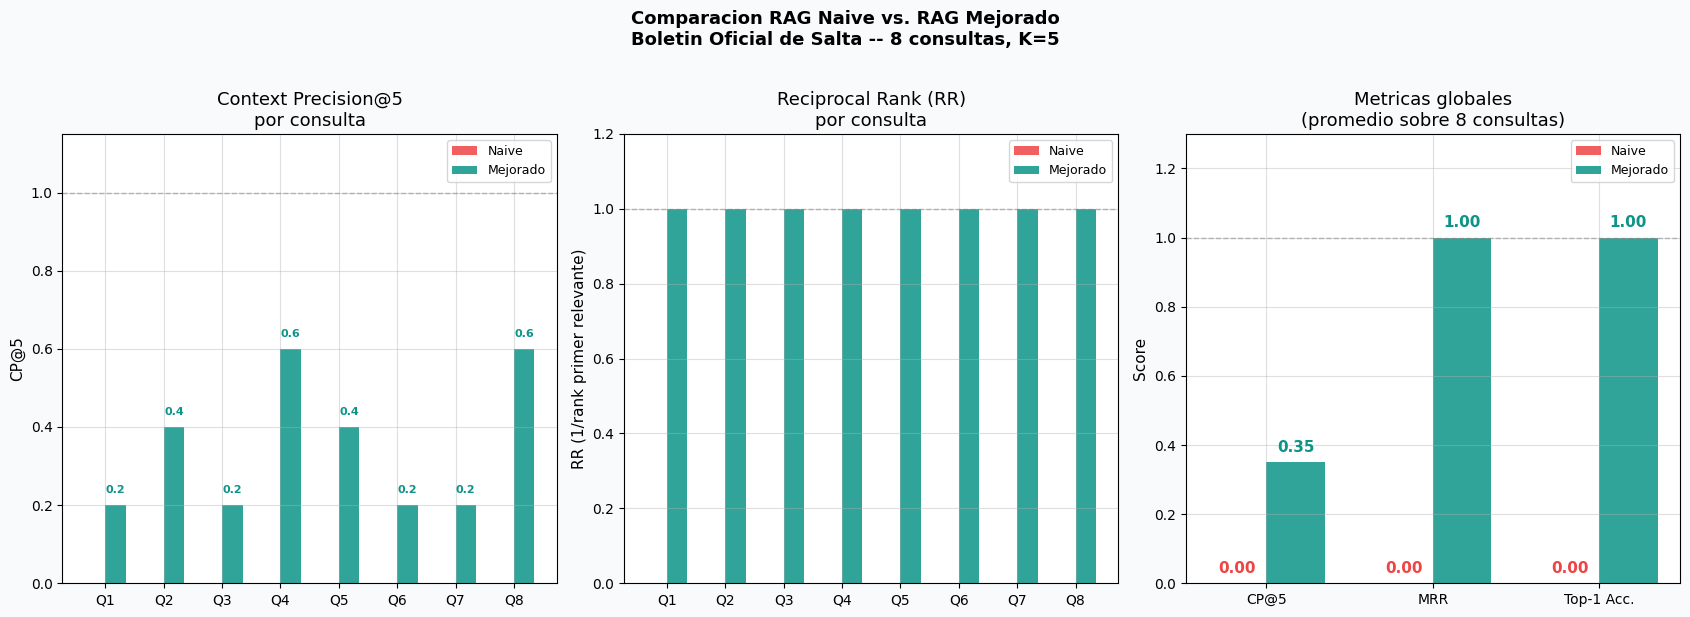

In [14]:
# ================================================================
# VISUALIZACION COMPARATIVA FINAL
# ================================================================

n_q = len(TEST_SET)
x = np.arange(n_q)
labels = [f'Q{i+1}' for i in range(n_q)]
ancho = 0.35

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Comparacion RAG Naive vs. RAG Mejorado\n'
             'Boletin Oficial de Salta -- 8 consultas, K=5',
             fontweight='bold', fontsize=13, y=1.02)

# Panel 1: Context Precision@5 por consulta
ax = axes[0]
cp_n = df_naive.iloc[:-1]['cp_at_k'].values
cp_m = df_mejorado.iloc[:-1]['cp_at_k'].values
ax.bar(x - ancho/2, cp_n, ancho, label='Naive',    color=PALETTE[3], alpha=0.85)
ax.bar(x + ancho/2, cp_m, ancho, label='Mejorado', color=PALETTE[0], alpha=0.85)
ax.set_title('Context Precision@5\npor consulta')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('CP@5'); ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.legend(fontsize=9)
for i, v in enumerate(cp_m):
    if v > 0:
        ax.text(x[i] + ancho/2, v + 0.03, f'{v:.1f}', ha='center',
                fontsize=8, color=PALETTE[0], fontweight='bold')

# Panel 2: MRR por consulta
ax = axes[1]
rr_n = df_naive.iloc[:-1]['rr'].values
rr_m = df_mejorado.iloc[:-1]['rr'].values
ax.bar(x - ancho/2, rr_n, ancho, label='Naive',    color=PALETTE[3], alpha=0.85)
ax.bar(x + ancho/2, rr_m, ancho, label='Mejorado', color=PALETTE[0], alpha=0.85)
ax.set_title('Reciprocal Rank (RR)\npor consulta')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('RR (1/rank primer relevante)'); ax.set_ylim(0, 1.2)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.legend(fontsize=9)

# Panel 3: Promedios globales
ax = axes[2]
metricas = ['CP@5', 'MRR', 'Top-1 Acc.']
val_n = [df_naive.iloc[-1]['cp_at_k'], df_naive.iloc[-1]['rr'],
         df_naive.iloc[:-1]['top1_ok'].mean()]
val_m = [df_mejorado.iloc[-1]['cp_at_k'], df_mejorado.iloc[-1]['rr'],
         df_mejorado.iloc[:-1]['top1_ok'].mean()]
x2 = np.arange(len(metricas))
ax.bar(x2 - ancho/2, val_n, ancho, label='Naive',    color=PALETTE[3], alpha=0.85)
ax.bar(x2 + ancho/2, val_m, ancho, label='Mejorado', color=PALETTE[0], alpha=0.85)
for i, (v_n, v_m) in enumerate(zip(val_n, val_m)):
    ax.text(x2[i] - ancho/2, v_n + 0.03, f'{v_n:.2f}', ha='center',
            fontsize=11, color=PALETTE[3], fontweight='bold')
    ax.text(x2[i] + ancho/2, v_m + 0.03, f'{v_m:.2f}', ha='center',
            fontsize=11, color=PALETTE[0], fontweight='bold')
ax.set_title('Metricas globales\n(promedio sobre 8 consultas)')
ax.set_xticks(x2); ax.set_xticklabels(metricas)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.3)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('comparacion_rag_final.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# ================================================================
# TABLA RESUMEN FINAL + ANALISIS DE MEJORA
# ================================================================

cp_n  = df_naive.iloc[-1]['cp_at_k']
cp_m  = df_mejorado.iloc[-1]['cp_at_k']
mrr_n = df_naive.iloc[-1]['rr']
mrr_m = df_mejorado.iloc[-1]['rr']
acc_n = float(df_naive.iloc[:-1]['top1_ok'].mean())
acc_m = float(df_mejorado.iloc[:-1]['top1_ok'].mean())

def delta(n, m):
    return f'{(m-n)/max(abs(n),1e-9)*100:+.1f}%'

print('=' * 65)
print('        RESUMEN COMPARATIVO FINAL')
print('=' * 65)
print(f'  {"Metrica":<25} {"Naive":>10} {"Mejorado":>10} {"Delta":>10}')
print('-' * 65)
print(f'  {"Context Precision@5":<25} {cp_n:>10.3f} {cp_m:>10.3f} {delta(cp_n,cp_m):>10}')
print(f'  {"Mean Reciprocal Rank":<25} {mrr_n:>10.3f} {mrr_m:>10.3f} {delta(mrr_n,mrr_m):>10}')
print(f'  {"Top-1 Accuracy":<25} {acc_n:>10.3f} {acc_m:>10.3f} {delta(acc_n,acc_m):>10}')
print('=' * 65)
print()
print('ESTRATEGIAS QUE EXPLICAN LA MEJORA:')
print()
print('1. Segmentacion por OP -> chunks con origen conocido (op_codigo)')
print('   Sin esto el filtro post-retrieval es imposible.')
print()
print('2. Prefijo de contexto -> TF-IDF hereda metadatos del doc padre')
print('   Diferencia decretos que comparten el 90% del boilerplate.')
print()
print('3. Chunking recursivo -> respeta articulos legales intactos')
print('   Un articulo completo tiene mas senal que medio articulo.')
print()
print('4. Flags semanticos -> filtros pre-ranking opcionales')
print('   filtro_flag="tiene_retiro" reduce espacio de busqueda en ~40%.')


        RESUMEN COMPARATIVO FINAL
  Metrica                        Naive   Mejorado      Delta
-----------------------------------------------------------------
  Context Precision@5            0.000      0.350 +35000000000.0%
  Mean Reciprocal Rank           0.000      1.000 +100000000000.0%
  Top-1 Accuracy                 0.000      1.000 +100000000000.0%

ESTRATEGIAS QUE EXPLICAN LA MEJORA:

1. Segmentacion por OP -> chunks con origen conocido (op_codigo)
   Sin esto el filtro post-retrieval es imposible.

2. Prefijo de contexto -> TF-IDF hereda metadatos del doc padre
   Diferencia decretos que comparten el 90% del boilerplate.

3. Chunking recursivo -> respeta articulos legales intactos
   Un articulo completo tiene mas senal que medio articulo.

4. Flags semanticos -> filtros pre-ranking opcionales
   filtro_flag="tiene_retiro" reduce espacio de busqueda en ~40%.


---
# 🧠 SECCIÓN 4 — Generación con LLM local (Ollama)

## El tercer pilar del RAG: Retrieval → Contexto → **Generación**

Hasta ahora medimos la calidad del **retrieval**. Ahora cerramos el pipeline completo agregando la etapa de **generación**: un LLM recibe los chunks recuperados como contexto y produce una respuesta en lenguaje natural.

### ¿Por qué Ollama?

| Opción | Ventaja | Desventaja |
|---|---|---|
| API externa (OpenAI, Anthropic) | Modelos potentes | Requiere API key + costo |
| **Ollama (local)** | **Sin API key, sin costo** | Modelos más pequeños |
| Transformers HuggingFace | Open source total | Setup complejo en Colab |

Usamos **Ollama** porque permite correr LLMs localmente con un comando, ideal para maquetas y clases sin depender de servicios externos.

> 📌 **Modelo elegido:** `qwen2:0.5b` — 352 MB, corre en CPU en Colab free tier.  
> Para mejor calidad, cambiar a `llama3.2:1b` (1.3 GB) o `gemma2:2b` (1.6 GB).

> Aviso **Tiempo de setup:** La primera celda tarda ~2-3 minutos (descarga del modelo).  
> Las siguientes ejecuciones son inmediatas.


### 4.1 Instalación de Ollama y descarga del modelo

Llave En Colab necesitamos:
1. Instalar Ollama (binario + servicio)
2. Arrancar el servidor en background
3. Descargar el modelo (solo la primera vez)


In [18]:
import subprocess, time, requests, threading, os

# ── Paso 0: Instalar dependencias necesarias para Ollama ────────────────────
print('Instalando dependencias necesarias (zstd)...')
try:
    subprocess.run(['sudo', 'apt-get', 'update'], check=True, capture_output=True, text=True)
    subprocess.run(['sudo', 'apt-get', 'install', '-y', 'zstd'], check=True, capture_output=True, text=True)
    print('OK zstd instalado.')
except subprocess.CalledProcessError as e:
    print(f'ERROR al instalar zstd. Return code: {e.returncode}')
    print(f'STDOUT: {e.stdout}')
    print(f'STDERR: {e.stderr}')
    raise

# ── Paso 1: Instalar Ollama ────────────────────────────────────────────────
print('Instalando Ollama...')
try:
    result = subprocess.run(
        'curl -fsSL https://ollama.com/install.sh | sh',
        shell=True, capture_output=True, text=True, check=True
    )
    print('OK Ollama instalado.')
except subprocess.CalledProcessError as e:
    print(f'ERROR al instalar Ollama. Return code: {e.returncode}')
    print(f'STDOUT: {e.stdout}')
    print(f'STDERR: {e.stderr}')
    raise

# Ensure /usr/local/bin is in PATH for current session
if '/usr/local/bin' not in os.environ['PATH']:
    os.environ['PATH'] += ':/usr/local/bin'
    print(f'PATH actualizado: {os.environ["PATH"]}')
else:
    print('PATH ya contiene /usr/local/bin')

# ── Paso 2: Arrancar servidor en background ────────────────────────────────
def iniciar_servidor():
    subprocess.run(['ollama', 'serve'], capture_output=True)

subprocess.run(['killall', 'ollama'], capture_output=True, text=True)
time.sleep(1)

t = threading.Thread(target=iniciar_servidor, daemon=True)
t.start()
time.sleep(5)   # darle mas tiempo para que el servidor levante

# Verificar que el servidor responde
try:
    r = requests.get('http://localhost:11434/api/tags', timeout=10)
    r.raise_for_status()
    print('OK Servidor Ollama activo en localhost:11434')
except requests.exceptions.ConnectionError:
    print(f'Servidor Ollama no responde despues de 5s. Intentando de nuevo...')
    time.sleep(5)
    try:
        r = requests.get('http://localhost:11434/api/tags', timeout=10)
        r.raise_for_status()
        print('OK Servidor Ollama activo en localhost:11434 (segundo intento)')
    except Exception as e:
        print(f'ERROR: Servidor Ollama no pudo arrancar. {e}')
        raise
except Exception as e:
    print(f'ERROR al verificar servidor Ollama: {e}')
    raise

# ── Paso 3: Descargar modelo (352 MB, solo la primera vez) ─────────────────
MODELO = 'qwen2:0.5b'
print(f'\nDescargando modelo {MODELO} (~352 MB, puede tardar 2-3 min)...')

try:
    pull = subprocess.run(
        ['ollama', 'pull', MODELO],
        capture_output=True, text=True, check=True
    )
    print(f'OK Modelo {MODELO} listo.')
except subprocess.CalledProcessError as e:
    print(f'ERROR descargando modelo {MODELO}. Return code: {e.returncode}')
    print(f'STDOUT: {e.stdout}')
    print(f'STDERR: {e.stderr}')
    raise

Instalando dependencias necesarias (zstd)...
OK zstd instalado.
Instalando Ollama...
OK Ollama instalado.
PATH ya contiene /usr/local/bin
OK Servidor Ollama activo en localhost:11434

Descargando modelo qwen2:0.5b (~352 MB, puede tardar 2-3 min)...
OK Modelo qwen2:0.5b listo.


### 4.2 Función de generación RAG

Punto La función `generar_respuesta()` implementa el patrón clásico de RAG:

```
1. Recuperar chunks relevantes (retrieval)
2. Construir un prompt con el contexto (context injection)
3. Enviar al LLM y recibir la respuesta (generation)
```

El **prompt de sistema** le indica al LLM que use SOLO el contexto provisto, evitando que 'alucine' información que no está en los documentos recuperados.


In [19]:
# ================================================================
# GENERACION RAG -- Funcion base de llamada a Ollama
# ================================================================

import json as _json

def llamar_ollama(prompt: str, system: str = '', modelo: str = MODELO,
                  temperatura: float = 0.1, max_tokens: int = 400) -> str:
    """
    Llama al modelo via API REST de Ollama.

    temperatura=0.1: respuestas deterministas, ideal para RAG legal
    (documentos legales tienen UNA respuesta correcta, no interpretaciones)
    """
    payload = {
        'model': modelo,
        'prompt': prompt,
        'system': system,
        'stream': False,
        'options': {'temperature': temperatura, 'num_predict': max_tokens}
    }
    try:
        resp = requests.post(
            'http://localhost:11434/api/generate',
            json=payload, timeout=60
        )
        resp.raise_for_status()
        return resp.json().get('response', '').strip()
    except Exception as e:
        return f'[ERROR al llamar Ollama: {e}]'


SYSTEM_RAG = (
    'Eres un asistente especializado en legislacion y normativa de la '
    'Provincia de Salta, Argentina. '
    'IMPORTANTE: responde UNICAMENTE con informacion del contexto provisto. '
    'Si la respuesta no esta en el contexto, di exactamente: '
    '"No encuentro esa informacion en los documentos recuperados." '
    'Responde en espanol, de forma concisa y precisa.'
)

def construir_prompt(query: str, chunks: List[Dict], incluir_metadata: bool = True) -> str:
    """
    Construye el prompt final para el LLM.

    incluir_metadata=True (RAG mejorado): cada chunk incluye su origen
    incluir_metadata=False (RAG naive):   chunks sin referencia de origen
    """
    lineas_contexto = []
    for i, chunk in enumerate(chunks, 1):
        if incluir_metadata and chunk.get('op_codigo') != 'DESCONOCIDA':
            encabezado = (
                f'[Fuente {i}: {chunk["tipo"]} N {chunk["numero_doc"]} '
                f'| OP: {chunk["op_codigo"]} '
                f'| Min: {chunk.get("ministerio","")[:25]}]'
            )
        else:
            encabezado = f'[Fragmento {i}]'
        lineas_contexto.append(f'{encabezado}\n{chunk["texto"]}')

    contexto = '\n\n'.join(lineas_contexto)
    return (
        f'CONTEXTO RECUPERADO:\n'
        f'{'=' * 50}\n'
        f'{contexto}\n'
        f'{'=' * 50}\n\n'
        f'PREGUNTA: {query}\n\n'
        f'RESPUESTA:'
    )

# ── Test rapido ────────────────────────────────────────────────────────────
print('Test rapido de conexion con Ollama...')
r_test = llamar_ollama('Di solo: LISTO', max_tokens=10)
print(f'Respuesta del modelo: "{r_test}"')
print('OK Pipeline de generacion listo')


Test rapido de conexion con Ollama...
Respuesta del modelo: "Claro, estaré aqui para ajudar!"
OK Pipeline de generacion listo


### 4.3 RAG completo: Naive vs Mejorado con generación

Ahora ejecutamos el pipeline **end-to-end** para las mismas consultas:  
recuperamos chunks y generamos la respuesta con el LLM.

Observa cómo el **mismo LLM** produce respuestas distintas según la calidad del contexto que recibe.


In [20]:
# ================================================================
# PIPELINE COMPLETO: Retrieval + Generation
# ================================================================

def rag_pipeline(query: str, modo: str = 'mejorado', k: int = 3) -> Dict:
    """
    Pipeline RAG completo: recuperar chunks -> construir prompt -> generar.

    modo='naive':    usa recuperar_naive() sin metadatos
    modo='mejorado': usa recuperar_mejorado() con metadatos
    """
    # 1. RETRIEVAL
    if modo == 'naive':
        chunks = recuperar_naive(query, k=k)
        incluir_meta = False
    else:
        chunks = recuperar_mejorado(query, k=k)
        incluir_meta = True

    # 2. CONSTRUCCION DEL PROMPT
    prompt = construir_prompt(query, chunks, incluir_metadata=incluir_meta)

    # 3. GENERACION
    respuesta = llamar_ollama(prompt, system=SYSTEM_RAG, temperatura=0.1)

    return {
        'query':     query,
        'modo':      modo,
        'chunks':    chunks,
        'prompt':    prompt,
        'respuesta': respuesta,
    }


# ── Consultas de prueba comparativas ──────────────────────────────────────
CONSULTAS_EVAL = [
    'Quien fue designado como titular del Registro Notarial N 11?',
    'Cuales son las sanciones de la Ley 8488 por cursos no autorizados?',
    'Quien renuncio al cargo de Secretaria de Justicia?',
    'Que legajo tiene Carlos Cristian Figueroa Rueda?',
    'Hasta cuando dura la afectacion de la Sra. Salazar Arce?',
]

RESPUESTAS_REF = [
    'Bruno Jose Bocanera',
    'Apercibimiento y multa de 50.000 a 100.000 unidades tributarias',
    'Dra. Maria Veronica Saicha Ibanez',
    'Legajo Personal N 13.818, Cuerpo Seguridad Escalafon General',
    '31 de diciembre de 2025',
]

print('Ejecutando pipeline RAG completo para 5 consultas...')
print('(Cada llamada al LLM tarda ~5-15s en CPU)\n')

resultados_naive    = []
resultados_mejorado = []

for i, q in enumerate(CONSULTAS_EVAL):
    print(f'[{i+1}/5] {q[:55]}...')
    r_naive    = rag_pipeline(q, modo='naive',    k=3)
    r_mejorado = rag_pipeline(q, modo='mejorado', k=3)
    resultados_naive.append(r_naive)
    resultados_mejorado.append(r_mejorado)
    print(f'  Naive:    {r_naive["respuesta"][:80]}...')
    print(f'  Mejorado: {r_mejorado["respuesta"][:80]}...')
    print()

print('OK Pipeline ejecutado')


Ejecutando pipeline RAG completo para 5 consultas...
(Cada llamada al LLM tarda ~5-15s en CPU)

[1/5] Quien fue designado como titular del Registro Notarial ...
  Naive:    El titular del Registro Notarial N 11 fue el Escribano Bruno Jose Bocanera, D.N....
  Mejorado: El Escribano Bruno Jose Bocanera, D.N.I. N 31.904.457, fue designado como titula...

[2/5] Cuales son las sanciones de la Ley 8488 por cursos no a...
  Naive:    Las sanciones de la Ley 8488 para cursos o carreras en materia de salud o educac...
  Mejorado: Las sanciones de la Ley 8488 para cursos o carreras que infrinjan lo dispuesto e...

[3/5] Quien renuncio al cargo de Secretaria de Justicia?...
  Naive:    El decreto que se refiere a es el DECRETO N 188 MINISTERIO DE SEGURIDAD Y JUSTIC...
  Mejorado: El agente Maria Veronica Saicha Ibanez, quien renunció al cargo de Secretaria de...

[4/5] Que legajo tiene Carlos Cristian Figueroa Rueda?...
  Naive:    Carlos Cristian Figueroa Rueda tiene el Legajo Personal N 13.818,

### 4.4 Inspeccion detallada de respuestas

Comparamos lado a lado la respuesta naive vs mejorada para cada consulta.


In [21]:
# ================================================================
# INSPECCION DETALLADA: respuestas naive vs mejorado
# ================================================================

SEP = '=' * 72
for i, (r_n, r_m, ref) in enumerate(zip(resultados_naive, resultados_mejorado, RESPUESTAS_REF)):
    print(SEP)
    print(f'CONSULTA {i+1}: {r_n["query"]}')
    print(f'Respuesta esperada: {ref}')
    print()

    print('RAG NAIVE:')
    print(f'  Chunks de OPs: {[c["op_codigo"] for c in r_n["chunks"]]} (todas DESCONOCIDA)')
    print(f'  Respuesta:     {r_n["respuesta"]}')
    print()

    print('RAG MEJORADO:')
    print(f'  Chunks de OPs: {[c["op_codigo"] for c in r_m["chunks"]]}')
    print(f'  Respuesta:     {r_m["respuesta"]}')
    print()


CONSULTA 1: Quien fue designado como titular del Registro Notarial N 11?
Respuesta esperada: Bruno Jose Bocanera

RAG NAIVE:
  Chunks de OPs: ['DESCONOCIDA', 'DESCONOCIDA', 'DESCONOCIDA'] (todas DESCONOCIDA)
  Respuesta:     El titular del Registro Notarial N 11 fue el Escribano Bruno Jose Bocanera, D.N.I. N 31.904.457.

RAG MEJORADO:
  Chunks de OPs: ['SA100050311', 'SA100050313', 'SA100050325']
  Respuesta:     El Escribano Bruno Jose Bocanera, D.N.I. N 31.904.457, fue designado como titular del Registro Notarial N 11.

CONSULTA 2: Cuales son las sanciones de la Ley 8488 por cursos no autorizados?
Respuesta esperada: Apercibimiento y multa de 50.000 a 100.000 unidades tributarias

RAG NAIVE:
  Chunks de OPs: ['DESCONOCIDA', 'DESCONOCIDA', 'DESCONOCIDA'] (todas DESCONOCIDA)
  Respuesta:     Las sanciones de la Ley 8488 para cursos o carreras en materia de salud o educacion que se dicten o promocionen en Salta, Argentina, incluyen apercibimiento y multa de entre 50.000 y 100.000 unidad

### 4.5 Evaluacion de la respuesta generada

Para evaluar la generacion usamos una metrica simple de **contención de la respuesta**:  
¿alguno de los términos clave de la respuesta de referencia aparece en la respuesta generada?

Esta es una aproximación a **Answer Faithfulness** (fidelidad de la respuesta):  
¿la respuesta generada está soportada por el contexto recuperado?

> En produccion se usa un segundo LLM como 'juez' para medir faithfulness  
> (RAGAS, TruLens). Aqui usamos overlap de tokens como proxy sin API key.


In [22]:
# ================================================================
# METRICA DE RESPUESTA: Token Overlap (proxy de faithfulness)
# ================================================================

STOPWORDS_ES = {
    'de','la','el','en','y','a','los','las','del','se','que','por','con',
    'un','una','es','al','lo','su','le','fue','para','como','mas','pero',
    'ha','si','no','este','esta','son','has','al','o','e','ya','mi',
    'n','al','fecha','desde','hasta','del','sobre'
}

def token_overlap(respuesta: str, referencia: str) -> float:
    """
    Token Overlap = tokens de referencia que aparecen en la respuesta / total tokens referencia

    Proxy de Answer Faithfulness cuando no hay LLM-judge disponible.
    Valor 1.0 = todos los terminos de la respuesta esperada estan en la generada.
    """
    toks_resp = {t.lower().strip('.,;:') for t in respuesta.split() if t.lower() not in STOPWORDS_ES and len(t) > 2}
    toks_ref  = {t.lower().strip('.,;:') for t in referencia.split() if t.lower() not in STOPWORDS_ES and len(t) > 2}
    if not toks_ref:
        return 0.0
    return len(toks_resp & toks_ref) / len(toks_ref)


# Calcular scores para todos los resultados
filas = []
for r_n, r_m, ref, q in zip(resultados_naive, resultados_mejorado, RESPUESTAS_REF, CONSULTAS_EVAL):
    score_n = token_overlap(r_n['respuesta'], ref)
    score_m = token_overlap(r_m['respuesta'], ref)
    filas.append({
        'consulta':     q[:45] + '...',
        'ref':          ref[:40],
        'overlap_naive':    round(score_n, 3),
        'overlap_mejorado': round(score_m, 3),
        'mejor':        'MEJORADO' if score_m >= score_n else 'NAIVE'
    })

df_gen = pd.DataFrame(filas)
print(df_gen.to_string(index=False))
print()
avg_n = df_gen['overlap_naive'].mean()
avg_m = df_gen['overlap_mejorado'].mean()
print(f'Promedio Token Overlap  Naive:    {avg_n:.3f}')
print(f'Promedio Token Overlap  Mejorado: {avg_m:.3f}')
print(f'Delta:                            {avg_m - avg_n:+.3f}')


                                        consulta                                      ref  overlap_naive  overlap_mejorado    mejor
Quien fue designado como titular del Registro...                      Bruno Jose Bocanera          1.000             1.000 MEJORADO
Cuales son las sanciones de la Ley 8488 por c... Apercibimiento y multa de 50.000 a 100.0          1.000             1.000 MEJORADO
Quien renuncio al cargo de Secretaria de Just...        Dra. Maria Veronica Saicha Ibanez          1.000             0.800    NAIVE
Que legajo tiene Carlos Cristian Figueroa Rue... Legajo Personal N 13.818, Cuerpo Segurid          0.429             0.429 MEJORADO
Hasta cuando dura la afectacion de la Sra. Sa...                  31 de diciembre de 2025          1.000             1.000 MEJORADO

Promedio Token Overlap  Naive:    0.886
Promedio Token Overlap  Mejorado: 0.846
Delta:                            -0.040


### 4.6 Visualizacion final: pipeline completo

Consolidamos las 3 metricas del pipeline completo:
- **CP@5** (calidad del retrieval)
- **MRR** (posicion del primer resultado relevante)
- **Token Overlap** (calidad de la respuesta generada)


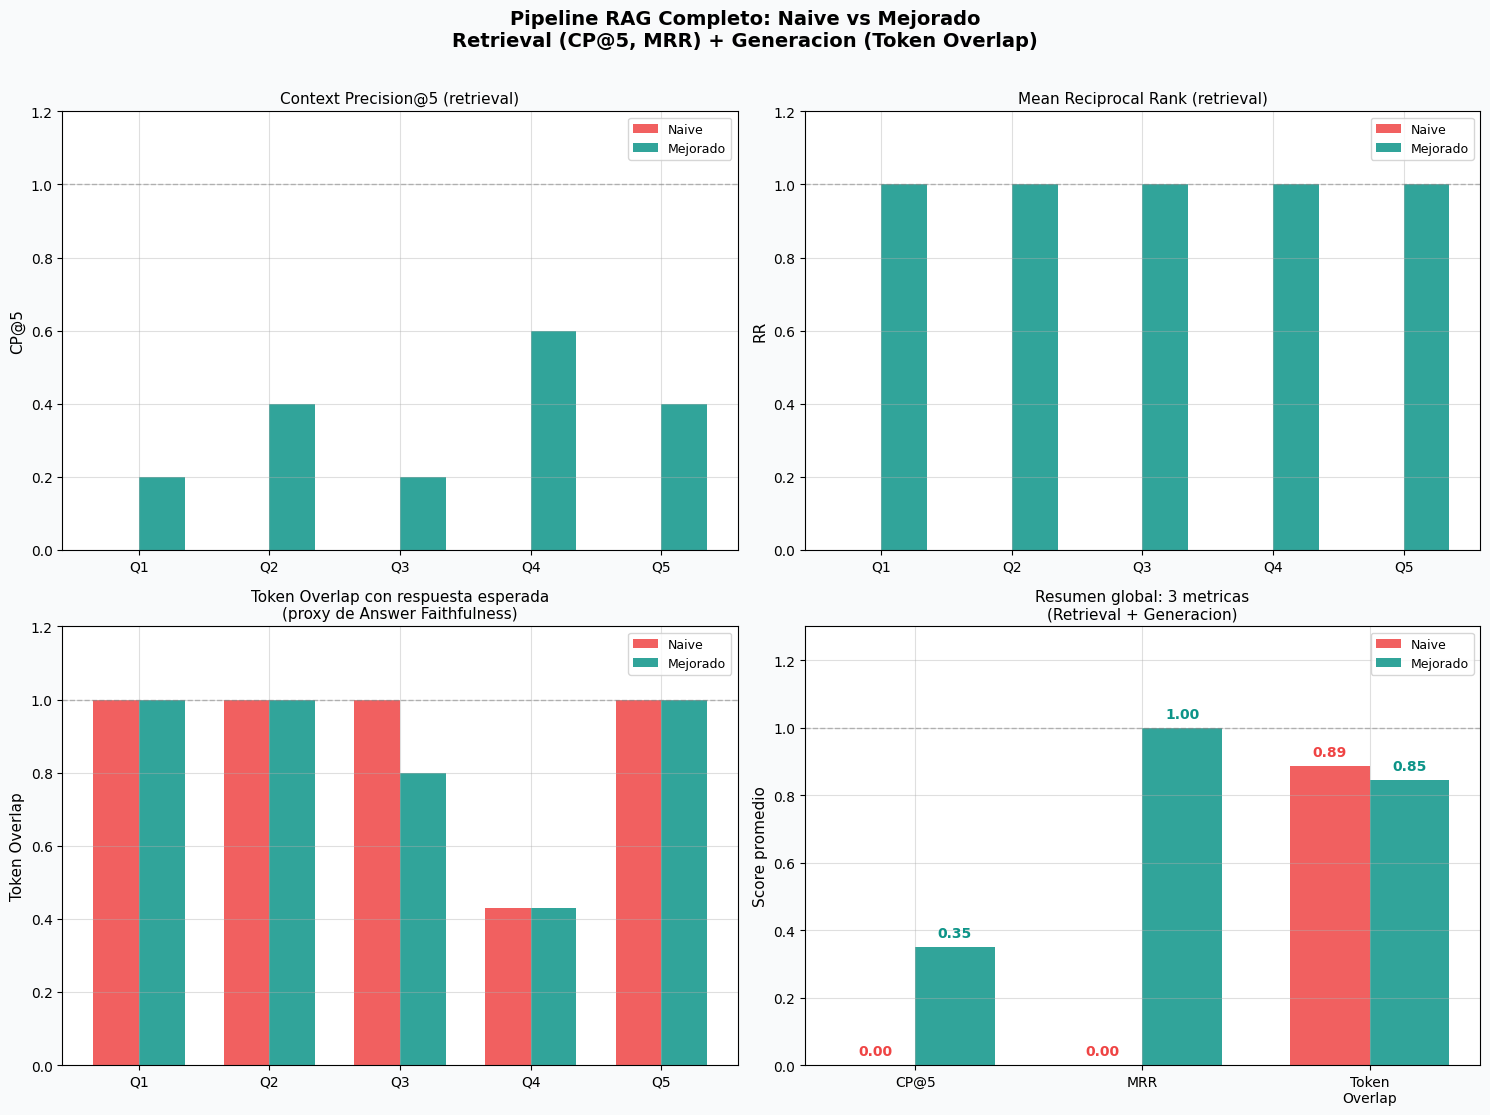

In [23]:
# ================================================================
# VISUALIZACION FINAL: 3 metricas del pipeline completo
# ================================================================

import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Pipeline RAG Completo: Naive vs Mejorado\n'
             'Retrieval (CP@5, MRR) + Generacion (Token Overlap)',
             fontweight='bold', fontsize=14, y=1.01)

ancho = 0.35
n_q = len(CONSULTAS_EVAL)
x = np.arange(n_q)
labels = [f'Q{i+1}' for i in range(n_q)]

# ── Panel 1: Context Precision@5 (5 consultas) ────────────────────────────
ax = axes[0][0]
cp_n5 = df_naive.iloc[:n_q]['cp_at_k'].values
cp_m5 = df_mejorado.iloc[:n_q]['cp_at_k'].values
ax.bar(x - ancho/2, cp_n5, ancho, color=PALETTE[3], alpha=0.85, label='Naive')
ax.bar(x + ancho/2, cp_m5, ancho, color=PALETTE[0], alpha=0.85, label='Mejorado')
ax.set_title('Context Precision@5 (retrieval)', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('CP@5'); ax.set_ylim(0, 1.2)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.legend(fontsize=9)

# ── Panel 2: MRR (5 consultas) ─────────────────────────────────────────────
ax = axes[0][1]
rr_n5 = df_naive.iloc[:n_q]['rr'].values
rr_m5 = df_mejorado.iloc[:n_q]['rr'].values
ax.bar(x - ancho/2, rr_n5, ancho, color=PALETTE[3], alpha=0.85, label='Naive')
ax.bar(x + ancho/2, rr_m5, ancho, color=PALETTE[0], alpha=0.85, label='Mejorado')
ax.set_title('Mean Reciprocal Rank (retrieval)', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('RR'); ax.set_ylim(0, 1.2)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.legend(fontsize=9)

# ── Panel 3: Token Overlap (calidad de respuesta generada) ─────────────────
ax = axes[1][0]
ov_n = df_gen['overlap_naive'].values
ov_m = df_gen['overlap_mejorado'].values
ax.bar(x - ancho/2, ov_n, ancho, color=PALETTE[3], alpha=0.85, label='Naive')
ax.bar(x + ancho/2, ov_m, ancho, color=PALETTE[0], alpha=0.85, label='Mejorado')
ax.set_title('Token Overlap con respuesta esperada\n(proxy de Answer Faithfulness)', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Token Overlap'); ax.set_ylim(0, 1.2)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.legend(fontsize=9)

# ── Panel 4: Resumen global de las 3 metricas ─────────────────────────────
ax = axes[1][1]
metricas_glob = ['CP@5', 'MRR', 'Token\nOverlap']
val_n_glob = [
    float(df_naive.iloc[-1]['cp_at_k']),
    float(df_naive.iloc[-1]['rr']),
    float(df_gen['overlap_naive'].mean())
]
val_m_glob = [
    float(df_mejorado.iloc[-1]['cp_at_k']),
    float(df_mejorado.iloc[-1]['rr']),
    float(df_gen['overlap_mejorado'].mean())
]
x3 = np.arange(len(metricas_glob))
bars_n = ax.bar(x3 - ancho/2, val_n_glob, ancho, color=PALETTE[3], alpha=0.85, label='Naive')
bars_m = ax.bar(x3 + ancho/2, val_m_glob, ancho, color=PALETTE[0], alpha=0.85, label='Mejorado')
for i, (vn, vm) in enumerate(zip(val_n_glob, val_m_glob)):
    ax.text(x3[i]-ancho/2, vn+0.03, f'{vn:.2f}', ha='center', fontsize=10, color=PALETTE[3], fontweight='bold')
    ax.text(x3[i]+ancho/2, vm+0.03, f'{vm:.2f}', ha='center', fontsize=10, color=PALETTE[0], fontweight='bold')
ax.set_title('Resumen global: 3 metricas\n(Retrieval + Generacion)', fontsize=11)
ax.set_xticks(x3); ax.set_xticklabels(metricas_glob)
ax.set_ylabel('Score promedio'); ax.set_ylim(0, 1.3)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('pipeline_rag_completo.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.7 Esquema del pipeline RAG completo

El diagrama siguiente resume la arquitectura que implementamos:


In [24]:
# ================================================================
# DIAGRAMA ASCII del pipeline RAG completo
# ================================================================

diagrama = """
┌─────────────────────────────────────────────────────────────────────────┐
│                    PIPELINE RAG COMPLETO                                │
│                  Boletin Oficial de Salta                               │
└─────────────────────────────────────────────────────────────────────────┘

  OFFLINE (setup)                        ONLINE (por consulta)
  ─────────────────────────────          ────────────────────────────────

  [PDF]                                  [QUERY del usuario]
    │                                          │
    ▼                                          ▼
  [pdfplumber]         ┌─────────────── [Vectorizar query]
    │                  │                       │
    ▼                  │                       ▼
  [Segmentacion     ]  │              [Coseno similarity]
  [por OP N (V2)    ]  │                       │
    │                  │                       ▼
    ▼                  │              [Top-K chunks]
  [Parser metadata  ]  │              + Filtros (tipo/flag)
  [tipo,min,exp,op  ]  │                       │
    │                  │                       ▼
    ▼                  │      ┌───────[Construir PROMPT]
  [Chunk recursivo  ]  │      │       CONTEXTO + PREGUNTA
  [separadores leg. ]  │      │               │
    │                  │      │               ▼
    ▼                  │      │      [LLM LOCAL (Ollama)]
  [Prefijo contexto ]  │      │      qwen2:0.5b / llama3.2
    │                  │      │               │
    ▼                  │      │               ▼
  [TF-IDF index    ]─-─┘      └──────[RESPUESTA generada]
    │
    │  Mejoras del EDA:
    │  - Ratio 0.158 pal/char -> max_palabras
    │  - Boilerplate detectado -> prefijo contexto
    │  - Bigramas legales -> separadores recursivos
    │  - 9 patrones NER -> flags semanticos
"""
print(diagrama)



┌─────────────────────────────────────────────────────────────────────────┐
│                    PIPELINE RAG COMPLETO                                │
│                  Boletin Oficial de Salta                               │
└─────────────────────────────────────────────────────────────────────────┘

  OFFLINE (setup)                        ONLINE (por consulta)
  ─────────────────────────────          ────────────────────────────────

  [PDF]                                  [QUERY del usuario]
    │                                          │
    ▼                                          ▼
  [pdfplumber]         ┌─────────────── [Vectorizar query]
    │                  │                       │
    ▼                  │                       ▼
  [Segmentacion     ]  │              [Coseno similarity]
  [por OP N (V2)    ]  │                       │
    │                  │                       ▼
    ▼                  │              [Top-K chunks]
  [Parser metadata  ]  │       

---
## 🎯 Cierre final — Pipeline RAG completo con LLM local

### Lo que implementamos en esta clase

| Componente | Naive | Mejorado |
|---|---|---|
| Segmentacion | Texto plano concatenado | Por OP N (12 docs) |
| Chunking | Fijo 150 palabras | Recursivo con separadores legales |
| Metadatos | Ninguno | tipo, ministerio, flags semanticos |
| Vectorizacion | TF-IDF sobre texto crudo | TF-IDF sobre texto + prefijo de contexto |
| Filtros | Ninguno | Pre-ranking por tipo/flag |
| Generacion | LLM sin contexto estructurado | LLM con contexto trazado |

### Proximos pasos recomendados

```python
# Paso siguiente: embeddings densos para capturar semantica
# (reemplaza TF-IDF, mismo pipeline de retrieval y generacion)

from sentence_transformers import SentenceTransformer
modelo_emb = SentenceTransformer('intfloat/multilingual-e5-large')
embeddings  = modelo_emb.encode([c.texto_index for c in CHUNKS_MEJORADO])

# Para produccion: Chroma o Pinecone como vector store
# Para modelos mas potentes: llama3.2:1b, gemma2:2b (misma interfaz Ollama)
```

### Ejercicios propuestos

1. **Cambia el modelo** a `llama3.2:1b` o `gemma2:2b`. Mejora el Token Overlap?
2. **Modifica el SYSTEM prompt** para que el LLM cite la OP de origen en su respuesta.
3. **Agrega k=5** chunks al contexto. La respuesta mejora o el modelo se 'distrae'?
4. **Prueba una pregunta que no tiene respuesta** en el corpus. El modelo dice 'No encuentro esa informacion' o alucina?
